# Olist E-Commerce Delivery Time Prediction
## Data Science Consulting Project

**Project Goal:** Predict delivery duration and identify key factors affecting delivery performance for Olist's e-commerce platform

**Date:** March 2026

---

## Table of Contents
1. Executive Summary
2. Business Context & Objectives
3. Data Loading & Overview
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Predictive Modeling
7. Model Evaluation & Results
8. Business Insights & Recommendations(TBD)
9. Conclusion & Next Steps(TBD)

---
## 1. Executive Summary

This project analyzes Olist's Brazilian e-commerce delivery data to:
- **Predict delivery duration** using machine learning models
- **Identify key factors** impacting delivery performance
- **Provide actionable recommendations** to improve customer satisfaction

**Key Findings:**
- Geographic distance is the strongest predictor of delivery time
- 93% of orders are delivered on time
- Customer and seller location, product characteristics, and order complexity all significantly impact delivery duration

**Business Impact:**
- Enable proactive delivery time estimation for customers
- Optimize logistics operations based on key drivers
- Improve customer satisfaction through better delivery management

---
## 2. Business Context & Objectives

### About Olist
Olist is a Brazilian e-commerce platform connecting small businesses with major marketplaces. Delivery performance is critical to customer satisfaction and platform success.

### Business Objectives
1. **Predict delivery duration** accurately for customer communication
2. **Identify bottlenecks** in the delivery process
3. **Optimize logistics** based on geographic and product factors
4. **Improve customer satisfaction** through better delivery experience

### Success Metrics
- Model accuracy (R² score, RMSE)
- Feature importance insights
- Actionable business recommendations

---
## 3. Data Loading & Overview

### Dataset Description
The Olist dataset contains information about:
- **Orders**: 99,441 orders from 2016-2018
- **Customers**: Geographic location and demographics
- **Sellers**: Brazilian merchants on the platform
- **Products**: Categories, dimensions, and weights
- **Payments**: Methods, installments, and values
- **Reviews**: Customer satisfaction scores

In [280]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Load datasets
customers = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_customers_dataset.csv")
geolocation = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_geolocation_dataset.csv")
orders = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_orders_dataset.csv")
order_items = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_order_items_dataset.csv")
order_payments = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_order_payments_dataset.csv")
order_reviews = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_order_reviews_dataset.csv")
products = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_products_dataset.csv")
sellers = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/olist_sellers_dataset.csv")
category_translation = pd.read_csv("/Users/malinaqin/Downloads/Olist Dataset (1)/product_category_name_translation.csv")

print("✓ All datasets loaded successfully")

✓ All datasets loaded successfully


In [281]:
# Preview each dataset
print("CUSTOMERS Dataset:")
print(customers.head())
print(f"\nShape: {customers.shape}")

print("\n" + "="*80)
print("ORDERS Dataset:")
print(orders.head())
print(f"\nShape: {orders.shape}")

print("\n" + "="*80)
print("ORDER ITEMS Dataset:")
print(order_items.head())
print(f"\nShape: {order_items.shape}")

print("\n" + "="*80)
print("ORDER PAYMENTS Dataset:")
print(order_payments.head())
print(f"\nShape: {order_payments.shape}")
print("\nNote: payment_sequential = order of payments for a single order")
print("payment_installments = Total number of installments for that order")

print("\n" + "="*80)
print("ORDER REVIEWS Dataset:")
print(order_reviews.head())
print(f"\nShape: {order_reviews.shape}")

print("\n" + "="*80)
print("PRODUCTS Dataset:")
print(products.head())
print(f"\nShape: {products.shape}")

print("\n" + "="*80)
print("SELLERS Dataset:")
print(sellers.head())
print(f"\nShape: {sellers.shape}")

print("\n" + "="*80)
print("CATEGORY TRANSLATION Dataset:")
print(category_translation.head())
print(f"\nShape: {category_translation.shape}")

CUSTOMERS Dataset:
                        customer_id                customer_unique_id  \
0  06b8999e2fba1a1fbc88172c00ba8bc7  861eff4711a542e4b93843c6dd7febb0   
1  18955e83d337fd6b2def6b18a428ac77  290c77bc529b7ac935b93aa66c333dc3   
2  4e7b3e00288586ebd08712fdd0374a03  060e732b5b29e8181a18229c7b0b2b5e   
3  b2b6027bc5c5109e529d4dc6358b12c3  259dac757896d24d7702b9acbbff3f3c   
4  4f2d8ab171c80ec8364f7c12e35b23ad  345ecd01c38d18a9036ed96c73b8d066   

   customer_zip_code_prefix          customer_city customer_state  
0                     14409                 franca             SP  
1                      9790  sao bernardo do campo             SP  
2                      1151              sao paulo             SP  
3                      8775        mogi das cruzes             SP  
4                     13056               campinas             SP  

Shape: (99441, 5)

ORDERS Dataset:
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49

In [282]:
# Data Quality Check
print("=" * 60)
print("DATA QUALITY ASSESSMENT")
print("=" * 60)

datasets = {
    'Orders': orders,
    'Customers': customers,
    'Sellers': sellers,
    'Products': products,
    'Order Items': order_items,
    'Payments': order_payments,
    'Reviews': order_reviews
}

for name, df in datasets.items():
    missing_pct = (df.isnull().sum().sum() / (df.shape[0] * df.shape[1])) * 100
    print(f"\n{name}:")
    print(f"  Rows: {df.shape[0]:,} | Columns: {df.shape[1]}")
    print(f"  Missing Data: {missing_pct:.2f}%")
    if missing_pct > 0:
        print(f"  Columns with missing: {df.columns[df.isnull().any()].tolist()}")

DATA QUALITY ASSESSMENT

Orders:
  Rows: 99,441 | Columns: 8
  Missing Data: 0.62%
  Columns with missing: ['order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date']

Customers:
  Rows: 99,441 | Columns: 5
  Missing Data: 0.00%

Sellers:
  Rows: 3,095 | Columns: 4
  Missing Data: 0.00%

Products:
  Rows: 32,951 | Columns: 9
  Missing Data: 0.83%
  Columns with missing: ['product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']

Order Items:
  Rows: 112,650 | Columns: 7
  Missing Data: 0.00%

Payments:
  Rows: 103,886 | Columns: 5
  Missing Data: 0.00%

Reviews:
  Rows: 99,224 | Columns: 7
  Missing Data: 21.01%
  Columns with missing: ['review_comment_title', 'review_comment_message']


---
## 4. Exploratory Data Analysis (EDA)

### 4.1 Delivery Duration and Status

In [283]:
# Calculate delivery duration
delivered_orders = orders[orders['order_status'] == 'delivered'].copy()
delivered_orders['actual_delivery_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])
delivered_orders['order_delivered_carrier_date'] = pd.to_datetime(delivered_orders['order_delivered_carrier_date'])

delivered_orders['delivery_duration'] = (
    delivered_orders['actual_delivery_date'] - delivered_orders['order_delivered_carrier_date']
).dt.days

print("Delivery Duration Statistics:")
print(f"Minimum: {delivered_orders['delivery_duration'].min()} days")
print(f"Maximum: {delivered_orders['delivery_duration'].max()} days")
print(f"Mean: {delivered_orders['delivery_duration'].mean():.2f} days")
print(f"Median: {delivered_orders['delivery_duration'].median():.2f} days")

print(f"\nMissing delivery_duration: {delivered_orders['delivery_duration'].isna().sum()}")

delivered_orders.head()

Delivery Duration Statistics:
Minimum: -17.0 days
Maximum: 205.0 days
Mean: 8.88 days
Median: 7.00 days

Missing delivery_duration: 9


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,actual_delivery_date,delivery_duration
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10-10 21:25:13,6.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-08-07 15:27:45,12.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08-17 18:06:29,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-12-02 00:28:42,9.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02-16 18:17:02,1.0


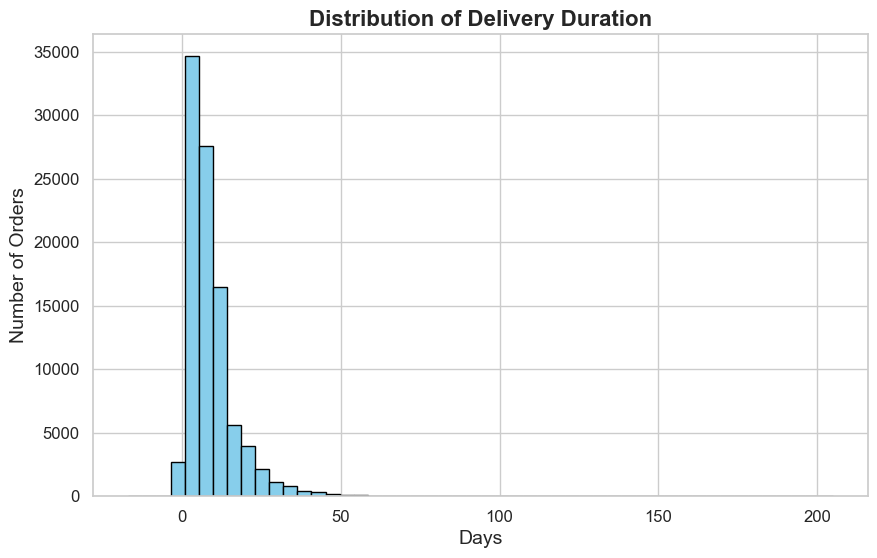


✓ Delivered orders ratio: 97.02%


In [284]:
# Visualization: Distribution of Delivery Duration
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.hist(delivered_orders['delivery_duration'], bins=50, color='skyblue', edgecolor='black') 
plt.title("Distribution of Delivery Duration", fontsize=16, fontweight='bold')
plt.xlabel("Days", fontsize=14)
plt.ylabel("Number of Orders", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Delivery ratio
delivered_ratio = len(delivered_orders) / len(orders)
print(f"\n✓ Delivered orders ratio: {delivered_ratio:.2%}")

### 4.2 On-time vs Delayed Deliveries

On-time deliveries: 93.22%
Delayed deliveries: 6.77%


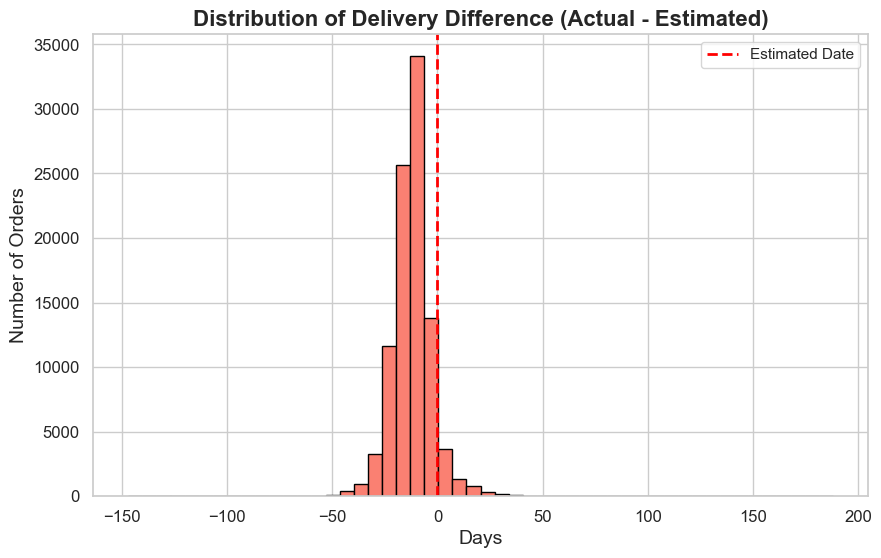

In [285]:
# Calculate delay
delivered_orders['estimated_delivery_date'] = pd.to_datetime(delivered_orders['order_estimated_delivery_date'])
delivered_orders['delay_days'] = (
    delivered_orders['actual_delivery_date'] - delivered_orders['estimated_delivery_date']
).dt.days

# On-time vs delayed
on_time = (delivered_orders['delay_days'] <= 0).mean()
delayed = (delivered_orders['delay_days'] > 0).mean()

print(f"On-time deliveries: {on_time:.2%}")
print(f"Delayed deliveries: {delayed:.2%}")

# Visualization: Delivery Difference (Actual - Estimated)
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.hist(delivered_orders['delay_days'], bins=50, color='salmon', edgecolor='black')
plt.title("Distribution of Delivery Difference (Actual - Estimated)", fontsize=16, fontweight='bold')
plt.xlabel("Days", fontsize=14)
plt.ylabel("Number of Orders", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Estimated Date')
plt.legend()
plt.show()

In [286]:
# Analyze delivery phases
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])
delivered_orders['order_approved_at'] = pd.to_datetime(delivered_orders['order_approved_at'])
delivered_orders['order_delivered_carrier_date'] = pd.to_datetime(delivered_orders['order_delivered_carrier_date'])
delivered_orders['order_delivered_customer_date'] = pd.to_datetime(delivered_orders['order_delivered_customer_date'])

# Purchase to Approval
delivered_orders['time_purchase_to_approval'] = (
    delivered_orders['order_approved_at'] - delivered_orders['order_purchase_timestamp']
).dt.days

# Approval to Shipped to carrier
delivered_orders['time_approval_to_carrier'] = (
    delivered_orders['order_delivered_carrier_date'] - delivered_orders['order_approved_at']
).dt.days

# Carrier to Delivered to customer (Actual Delivery Time)
delivered_orders['time_carrier_to_customer'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_delivered_carrier_date']
).dt.days

# Total delivery time
delivered_orders['total_delivery_time'] = (
    delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
).dt.days

# Display statistics
stage_stats = delivered_orders[['time_purchase_to_approval', 
                                'time_approval_to_carrier', 
                                'time_carrier_to_customer', 
                                'total_delivery_time']].describe()
print("Delivery Stage Statistics:")
print(stage_stats)

Delivery Stage Statistics:
       time_purchase_to_approval  time_approval_to_carrier  \
count               96464.000000              96462.000000   
mean                    0.264337                  2.295712   
std                     0.729926                  3.547926   
min                     0.000000               -172.000000   
25%                     0.000000                  0.000000   
50%                     0.000000                  1.000000   
75%                     0.000000                  3.000000   
max                    30.000000                125.000000   

       time_carrier_to_customer  total_delivery_time  
count              96469.000000         96470.000000  
mean                   8.878054            12.093604  
std                    8.745881             9.551380  
min                  -17.000000             0.000000  
25%                    4.000000             6.000000  
50%                    7.000000            10.000000  
75%                   12.0000

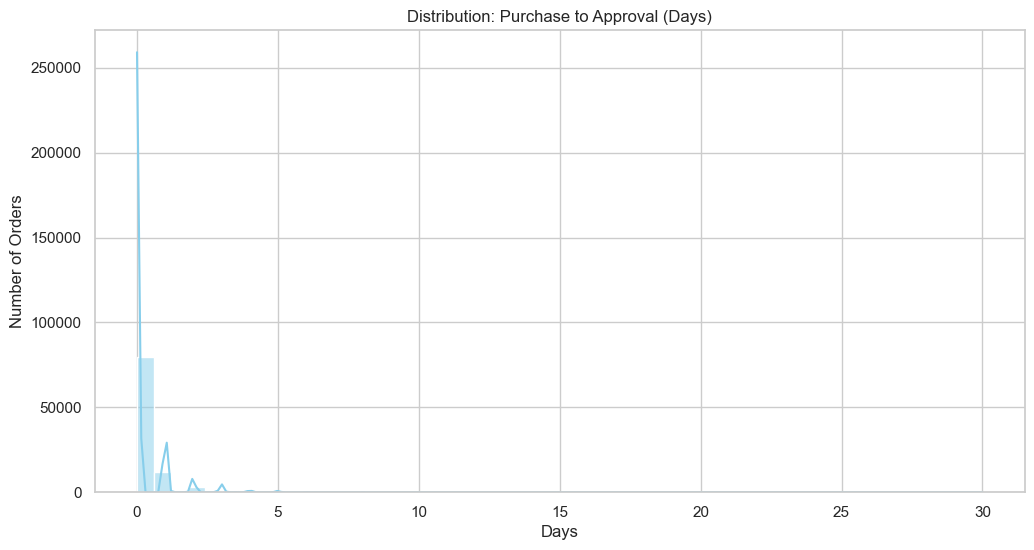

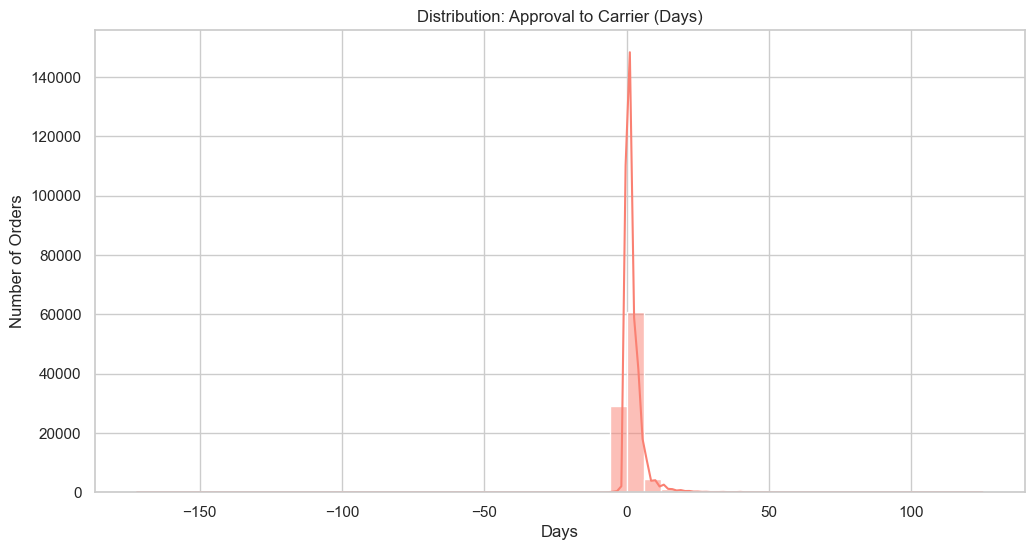

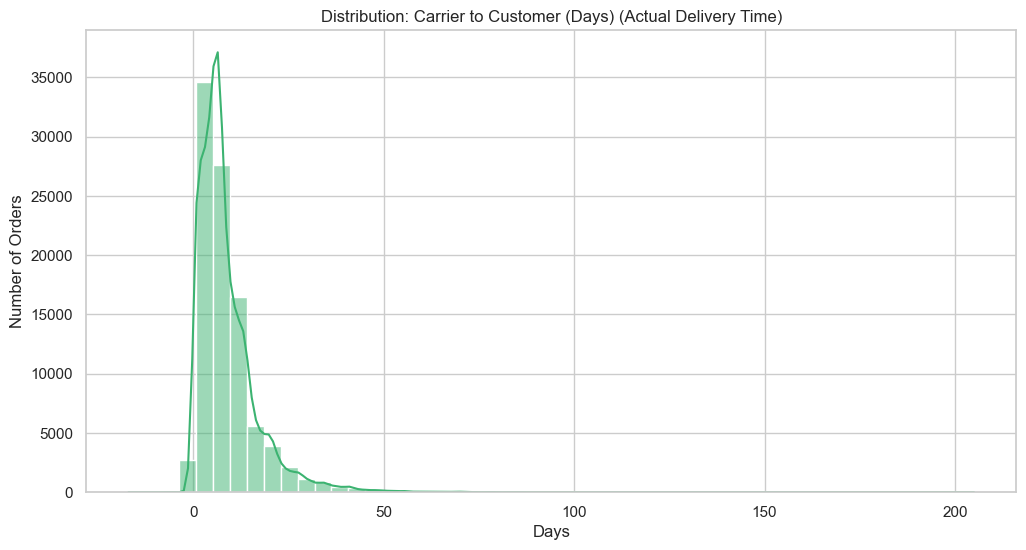

In [287]:
# Plot the distribution of the duration for each phase
sns.set(style="whitegrid")
plt.figure(figsize=(12,6))
sns.histplot(delivered_orders['time_purchase_to_approval'], bins=50, color='skyblue', kde=True)
plt.title("Distribution: Purchase to Approval (Days)")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(delivered_orders['time_approval_to_carrier'], bins=50, color='salmon', kde=True)
plt.title("Distribution: Approval to Carrier (Days)")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.show()

plt.figure(figsize=(12,6))
sns.histplot(delivered_orders['time_carrier_to_customer'], bins=50, color='mediumseagreen', kde=True)
plt.title("Distribution: Carrier to Customer (Days) (Actual Delivery Time)")
plt.xlabel("Days")
plt.ylabel("Number of Orders")
plt.show()

# Drop temporary columns not used in modeling
delivered_orders = delivered_orders.drop(['time_purchase_to_approval', 
                                'time_approval_to_carrier', 
                                'time_carrier_to_customer', 
                                'total_delivery_time'], axis=1)

In [288]:
### 4.3 Customer Location Analysis

In [289]:
# Integrate customer location with delivery time
# Convert ZIP code prefixes to string
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].astype(str)

# Aggregate geolocation by ZIP prefix to get median lat/lng (robust to outliers)
geo_agg = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].median().reset_index()

# Merge with customers
customers_geo = pd.merge(customers, geo_agg, left_on='customer_zip_code_prefix', 
                         right_on='geolocation_zip_code_prefix', how='left')

# Merge with delivered orders
orders_geo = pd.merge(delivered_orders, customers_geo, on='customer_id', how='left')

print("✓ Integrated orders with customer geographic data")
orders_geo[['order_id', 'delivery_duration', 'geolocation_lat', 'geolocation_lng']].head()

✓ Integrated orders with customer geographic data


,order_id,delivery_duration,geolocation_lat,geolocation_lng
0,e481f51cbdc54678b7cc49136f2d6af7,6.0,-23.576170,-46.587276
1,53cdb2fc8bc7dce0b6741e2150273451,12.0,-12.126651,-45.008162
2,47770eb9100c2d0c44946d9cf07ec65d,9.0,-16.744472,-48.514624
3,949d5b44dbf5de918fe9c16f97b45f8a,9.0,-5.774611,-35.273916
4,ad21c59c0840e6cb83a9ceb5573f8159,1.0,-23.675316,-46.515116


In [290]:
# Group by state to check mean delivery duration
customer_delivery = orders_geo.groupby('customer_state')['delivery_duration'].mean().reset_index()
customer_delivery = customer_delivery.sort_values(by='delivery_duration', ascending=False)

# Create Brazil choropleth map
import plotly.graph_objects as go

# State centroids for text labels (approximate lat/lon for Brazilian states)
state_centroids = {
    'AC': (-9.0, -70.0), 'AL': (-9.5, -36.6), 'AP': (1.4, -51.9), 'AM': (-4.0, -63.0),
    'BA': (-12.5, -41.5), 'CE': (-5.5, -39.5), 'DF': (-15.8, -47.9), 'ES': (-19.5, -40.5),
    'GO': (-15.8, -49.5), 'MA': (-5.0, -45.0), 'MT': (-12.5, -55.5), 'MS': (-20.5, -54.5),
    'MG': (-18.5, -44.0), 'PA': (-3.5, -52.5), 'PB': (-7.2, -36.7), 'PR': (-24.5, -51.5),
    'PE': (-8.3, -37.0), 'PI': (-7.5, -42.5), 'RJ': (-22.5, -42.8), 'RN': (-5.8, -36.5),
    'RS': (-30.0, -53.0), 'RO': (-11.0, -62.8), 'RR': (2.0, -61.0), 'SC': (-27.0, -50.5),
    'SP': (-23.0, -48.5), 'SE': (-10.6, -37.3), 'TO': (-10.2, -48.3)
}

# Add centroid coordinates to dataframe
customer_delivery['lat'] = customer_delivery['customer_state'].map(lambda x: state_centroids.get(x, (0, 0))[0])
customer_delivery['lon'] = customer_delivery['customer_state'].map(lambda x: state_centroids.get(x, (0, 0))[1])
customer_delivery['text_label'] = customer_delivery['customer_state'] + '<br>' + customer_delivery['delivery_duration'].round(1).astype(str)

# Create choropleth
fig = go.Figure()

fig.add_trace(go.Choropleth(
    locations=customer_delivery['customer_state'],
    z=customer_delivery['delivery_duration'],
    locationmode='geojson-id',
    geojson='https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson',
    featureidkey='properties.sigla',
    colorscale='Purples',
    colorbar_title="Avg Duration (days)",
    marker_line_color='white',
    marker_line_width=0.5,
    hovertemplate='<b>%{location}</b><br>Avg Duration: %{z:.1f} days<extra></extra>'
))

# Add text labels as Scattergeo overlay
fig.add_trace(go.Scattergeo(
    lon=customer_delivery['lon'],
    lat=customer_delivery['lat'],
    text=customer_delivery['text_label'],
    mode='text',
    textfont=dict(size=9, color='black', family='Arial, sans-serif'),
    hoverinfo='skip',
    showlegend=False
))

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    title_text='Average Shipping Duration by Customer State (days)',
    title_x=0.5,
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='mercator'
    ),
    height=600,
    width=800,
    font=dict(size=10)
)

fig.show()

print("\nTop 5 states with longest delivery duration:")
print(customer_delivery.head())


Top 5 states with longest delivery duration:
   customer_state  delivery_duration  lat   lon  text_label
21             RR          25.219512  2.0 -61.0  RR<br>25.2
3              AP          23.208955  1.4 -51.9  AP<br>23.2
2              AM          23.103448 -4.0 -63.0  AM<br>23.1
1              AL          20.609572 -9.5 -36.6  AL<br>20.6
13             PA          19.837209 -3.5 -52.5  PA<br>19.8


In [291]:
### 4.4 Seller Location Analysis

In [292]:
# Merge orders with order_items and sellers to get processing duration
delivery_seller = (
    orders[['order_id', 'order_approved_at', 'order_delivered_carrier_date']]
    .merge(order_items[['order_id', 'seller_id']], on='order_id', how='left')
    .merge(sellers[['seller_id', 'seller_city', 'seller_state']], on='seller_id', how='left')
)

# Calculate processing duration (approval to carrier pickup)
delivery_seller['processing_duration'] = (
    pd.to_datetime(delivery_seller['order_delivered_carrier_date']) - 
    pd.to_datetime(delivery_seller['order_approved_at'])
).dt.days

# Group by seller state
seller_delivery = delivery_seller.groupby('seller_state')['processing_duration'].mean().reset_index()
seller_delivery = seller_delivery.sort_values(by='processing_duration', ascending=False)

# Create Brazil choropleth map
import plotly.graph_objects as go

# State centroids for text labels (approximate lat/lon for Brazilian states)
state_centroids = {
    'AC': (-9.0, -70.0), 'AL': (-9.5, -36.6), 'AP': (1.4, -51.9), 'AM': (-4.0, -63.0),
    'BA': (-12.5, -41.5), 'CE': (-5.5, -39.5), 'DF': (-15.8, -47.9), 'ES': (-19.5, -40.5),
    'GO': (-15.8, -49.5), 'MA': (-5.0, -45.0), 'MT': (-12.5, -55.5), 'MS': (-20.5, -54.5),
    'MG': (-18.5, -44.0), 'PA': (-3.5, -52.5), 'PB': (-7.2, -36.7), 'PR': (-24.5, -51.5),
    'PE': (-8.3, -37.0), 'PI': (-7.5, -42.5), 'RJ': (-22.5, -42.8), 'RN': (-5.8, -36.5),
    'RS': (-30.0, -53.0), 'RO': (-11.0, -62.8), 'RR': (2.0, -61.0), 'SC': (-27.0, -50.5),
    'SP': (-23.0, -48.5), 'SE': (-10.6, -37.3), 'TO': (-10.2, -48.3)
}

# Add centroid coordinates to dataframe
seller_delivery['lat'] = seller_delivery['seller_state'].map(lambda x: state_centroids.get(x, (0, 0))[0])
seller_delivery['lon'] = seller_delivery['seller_state'].map(lambda x: state_centroids.get(x, (0, 0))[1])
seller_delivery['text_label'] = seller_delivery['seller_state'] + '<br>' + seller_delivery['processing_duration'].round(1).astype(str)

# Create choropleth
fig = go.Figure()

fig.add_trace(go.Choropleth(
    locations=seller_delivery['seller_state'],
    z=seller_delivery['processing_duration'],
    locationmode='geojson-id',
    geojson='https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson',
    featureidkey='properties.sigla',
    colorscale='Purples',
    colorbar_title="Avg Duration (days)",
    marker_line_color='white',
    marker_line_width=0.5,
    hovertemplate='<b>%{location}</b><br>Avg Duration: %{z:.1f} days<extra></extra>'
))

# Add text labels as Scattergeo overlay
fig.add_trace(go.Scattergeo(
    lon=seller_delivery['lon'],
    lat=seller_delivery['lat'],
    text=seller_delivery['text_label'],
    mode='text',
    textfont=dict(size=9, color='black', family='Arial, sans-serif'),
    hoverinfo='skip',
    showlegend=False
))

fig.update_geos(
    fitbounds="locations",
    visible=False
)

fig.update_layout(
    title_text='Average Processing Duration by Seller State (days)',
    title_x=0.5,
    geo=dict(
        showframe=False,
        showcoastlines=False,
        projection_type='mercator'
    ),
    height=600,
    width=800,
    font=dict(size=10)
)

fig.show()

print("\nTop 5 seller states with longest processing duration:")
print(seller_delivery.head())


Top 5 seller states with longest processing duration:
   seller_state  processing_duration   lat   lon text_label
7            MA             4.044444  -5.0 -45.0  MA<br>4.0
17           RN             3.375000  -5.8 -36.5  RN<br>3.4
9            MS             3.220000 -20.5 -54.5  MS<br>3.2
11           PA             2.750000  -3.5 -52.5  PA<br>2.8
1            AM             2.666667  -4.0 -63.0  AM<br>2.7


In [293]:
# Integrate seller location with geolocation
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str)
sellers_geo = pd.merge(sellers, geo_agg, left_on='seller_zip_code_prefix', 
                       right_on='geolocation_zip_code_prefix', how='left')

# Combine order -> order_items -> sellers
orders_items_sellers = order_items.merge(orders, on='order_id', how='left').merge(sellers_geo, on='seller_id', how='left')

# Compute delivery duration (in days)
orders_items_sellers['delivery_duration'] = (
    pd.to_datetime(orders_items_sellers['order_delivered_customer_date']) 
    - pd.to_datetime(orders_items_sellers['order_delivered_carrier_date'])
).dt.days

print("✓ Integrated seller geographic data with orders")
orders_items_sellers[['order_id', 'seller_id', 'seller_zip_code_prefix',
                      'geolocation_lat', 'geolocation_lng', 'delivery_duration']].head()

✓ Integrated seller geographic data with orders


,order_id,seller_id,seller_zip_code_prefix,geolocation_lat,geolocation_lng,delivery_duration
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,27277,-22.498419,-44.125272,1.0
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,3471,-23.564289,-46.519045,8.0
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,37564,-22.271648,-46.165556,6.0
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,14403,-20.554951,-47.387691,4.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,87900,-22.930408,-53.136438,13.0


### 4.5 Payment Analysis

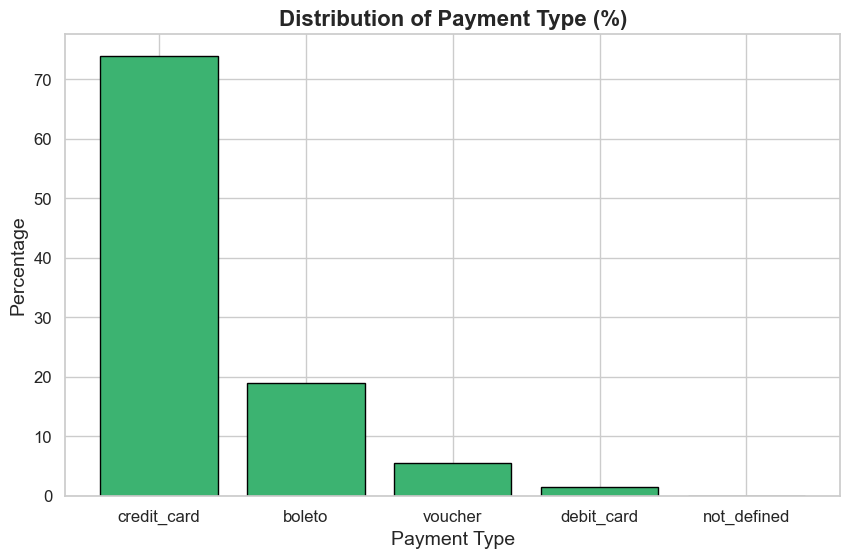


Payment type distribution:
payment_type
credit_card    73.922376
boleto         19.043952
voucher         5.558978
debit_card      1.471806
not_defined     0.002888
Name: proportion, dtype: float64

Payment Installments Statistics:
count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64


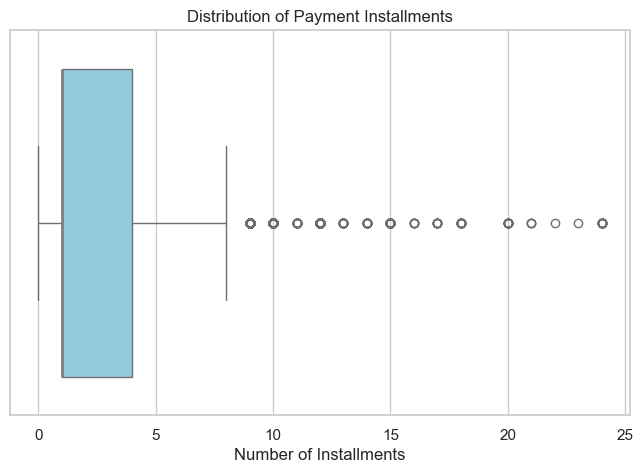

In [294]:
# Payment type distribution
payment_type_counts = order_payments['payment_type'].value_counts(normalize=True) * 100

sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.bar(payment_type_counts.index, payment_type_counts.values, color='mediumseagreen', edgecolor='black') 
plt.title("Distribution of Payment Type (%)", fontsize=16, fontweight='bold')
plt.xlabel("Payment Type", fontsize=14)
plt.ylabel("Percentage", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

print("\nPayment type distribution:")
print(payment_type_counts)

# Payment installments statistics
print("\n" + "="*80)
print("Payment Installments Statistics:")
print(order_payments['payment_installments'].describe())

# Boxplot for installments
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(x=order_payments['payment_installments'], color='skyblue',
            medianprops=dict(color='gray', linewidth=2))
plt.title("Distribution of Payment Installments")
plt.xlabel("Number of Installments")
plt.show()

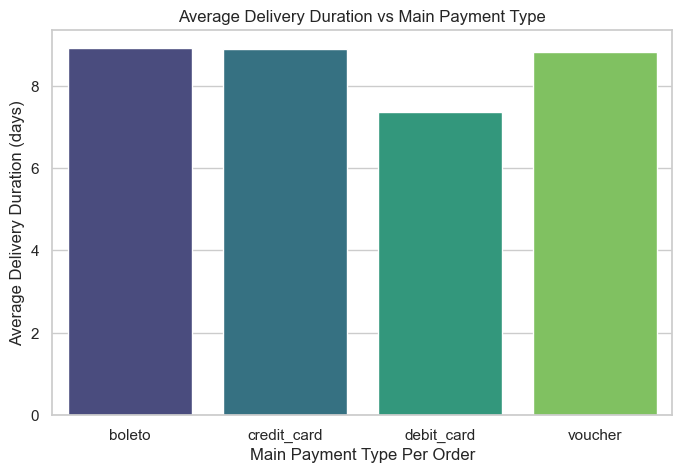

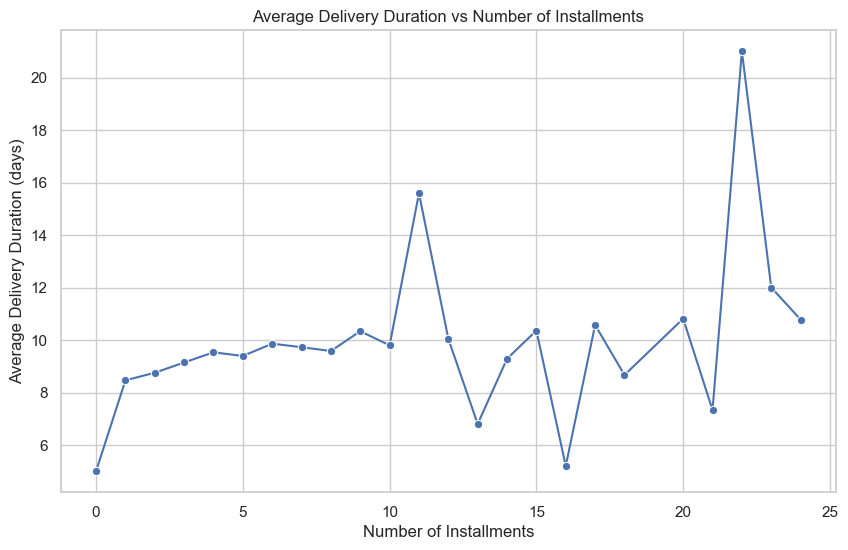

In [295]:
# Installment and Payment Type patterns with delivery duration
orders_payments_merged = pd.merge(
    delivered_orders[['order_id', 'delay_days', 'delivery_duration']],
    order_payments[['order_id', 'payment_type', 'payment_installments']],
    on='order_id',
    how='left'
)

# Select main payment_type in an order (mode)
def get_mode(series):
    return series.mode().iloc[0] if not series.mode().empty else None

order_payment_mode = orders_payments_merged.groupby('order_id')['payment_type'].apply(get_mode).reset_index()
order_payment_mode.rename(columns={'payment_type': 'main_payment_type'}, inplace=True)

payment_type_delivery_duration = orders_payments_merged[['order_id', 'delivery_duration']].drop_duplicates()
payment_type_delivery_duration = payment_type_delivery_duration.merge(order_payment_mode, on='order_id', how='left')

payment_type_avg = payment_type_delivery_duration.groupby('main_payment_type')['delivery_duration'].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(x='main_payment_type', y='delivery_duration', data=payment_type_avg, palette='viridis')
plt.xlabel("Main Payment Type Per Order")
plt.ylabel("Average Delivery Duration (days)")
plt.title("Average Delivery Duration vs Main Payment Type")
plt.show()

# Delivery duration vs installments
installment_delivery_duration = orders_payments_merged.groupby('payment_installments')['delivery_duration'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(x='payment_installments', y='delivery_duration', data=installment_delivery_duration, marker='o')
plt.xlabel("Number of Installments")
plt.ylabel("Average Delivery Duration (days)")
plt.title("Average Delivery Duration vs Number of Installments")
plt.show()

Payment Value Statistics:
count    103886.000000
mean        154.100380
std         217.494064
min           0.000000
25%          56.790000
50%         100.000000
75%         171.837500
max       13664.080000
Name: payment_value, dtype: float64


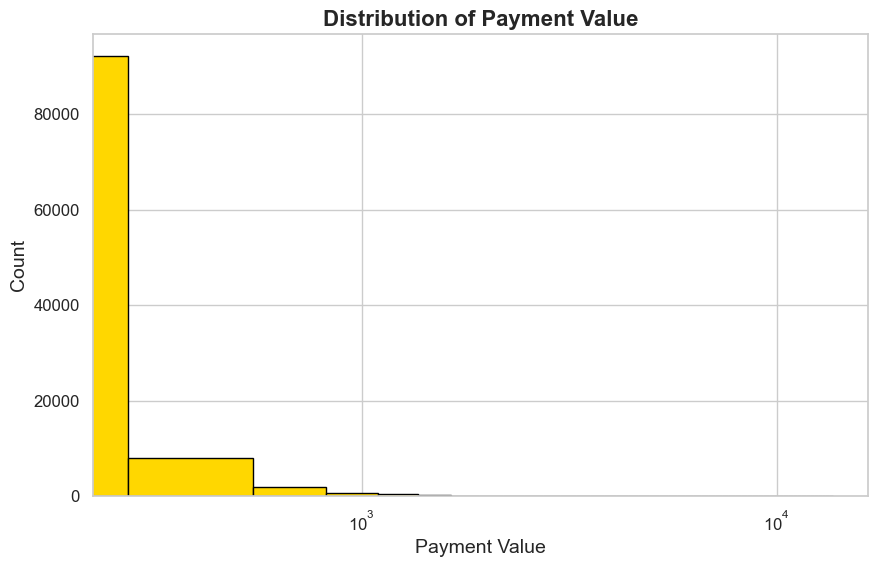

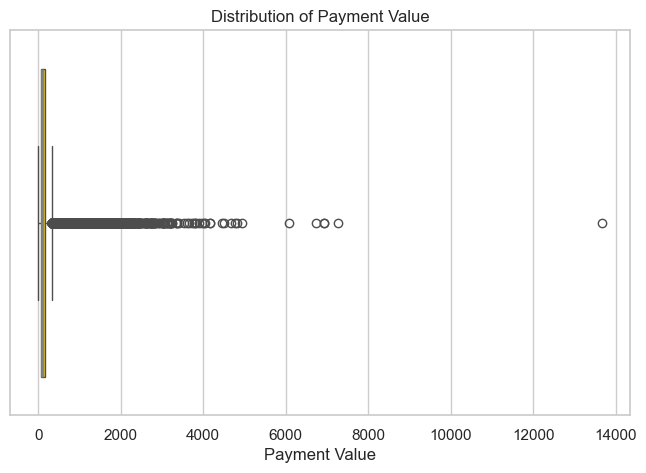


✓ Created order payment summary


,order_id,order_total,payment_installments
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2
1,00018f77f2f0320c557190d7a144bdd3,259.83,3
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,2
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3


In [296]:
# Payment value analysis
print("Payment Value Statistics:")
print(order_payments['payment_value'].describe())

# Histogram
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.hist(order_payments['payment_value'], bins=50, color='gold', edgecolor='black') 
plt.title("Distribution of Payment Value", fontsize=16, fontweight='bold')
plt.xlabel("Payment Value", fontsize=14)
plt.ylabel("Count", fontsize=14)
plt.xscale('log')
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

# Boxplot
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(x=order_payments['payment_value'], color='gold',
            medianprops=dict(color='gray', linewidth=2))
plt.title("Distribution of Payment Value")
plt.xlabel("Payment Value")
plt.show()

# Aggregate payment value by order
order_total = order_payments.groupby('order_id')['payment_value'].sum().reset_index() 
order_total.rename(columns={'payment_value': 'order_total'}, inplace=True) 

order_installments = order_payments.groupby('order_id')['payment_installments'].max().reset_index()

orders_payment_summary = pd.merge(order_total, order_installments, on='order_id')
print("\n✓ Created order payment summary")
orders_payment_summary.head()

In [297]:
### 4.6 Order Items Analysis

Unique orders: 98666
Total order items: 112650
Max items in an order: 21


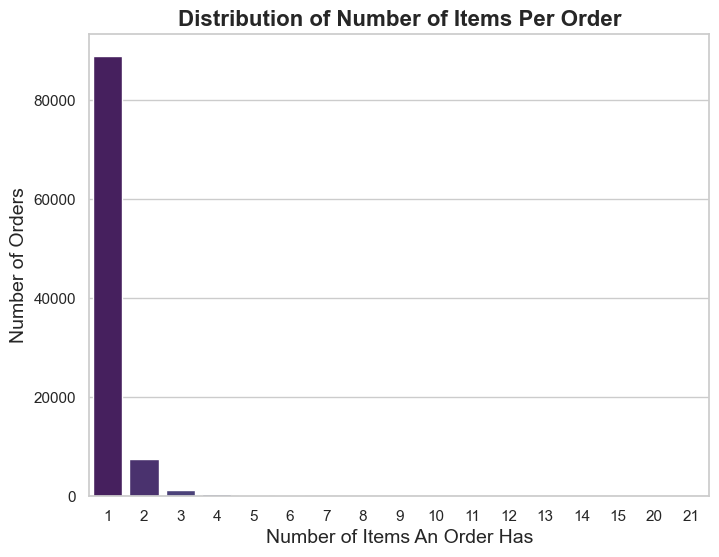

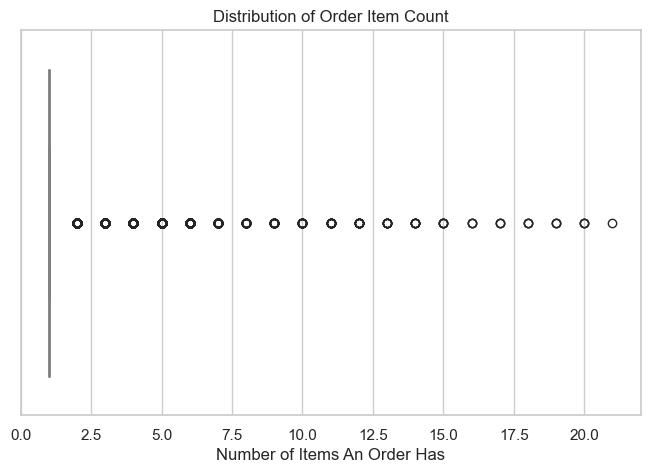

In [298]:
# Order item counts - how many items per order
print(f"Unique orders: {order_items['order_id'].nunique()}")
print(f"Total order items: {order_items['order_id'].count()}")
print(f"Max items in an order: {order_items['order_item_id'].max()}")

order_item_counts = order_items.groupby('order_id')['order_item_id'].nunique()
item_count_dist = order_item_counts.value_counts().sort_index()
item_count_df = item_count_dist.reset_index()
item_count_df.columns = ['order_item_id', 'num_orders']

plt.figure(figsize=(8,6))
sns.barplot(x='order_item_id', y='num_orders', data=item_count_df, palette='viridis')
plt.title("Distribution of Number of Items Per Order", fontsize=16, fontweight='bold')
plt.xlabel("Number of Items An Order Has", fontsize=14)
plt.ylabel("Number of Orders", fontsize=14)
plt.show()

# Boxplot
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(x=order_items['order_item_id'], color='purple',
            medianprops=dict(color='gray', linewidth=2))
plt.title("Distribution of Order Item Count")
plt.xlabel("Number of Items An Order Has")
plt.show()

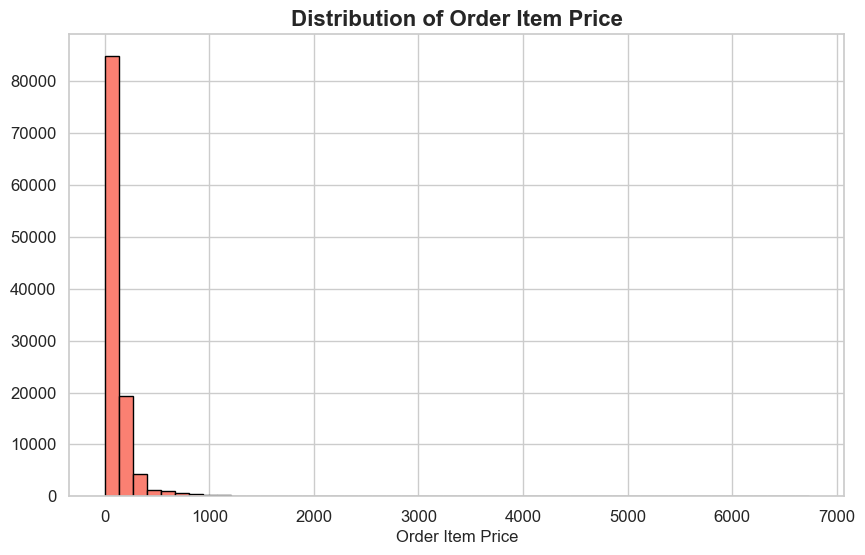

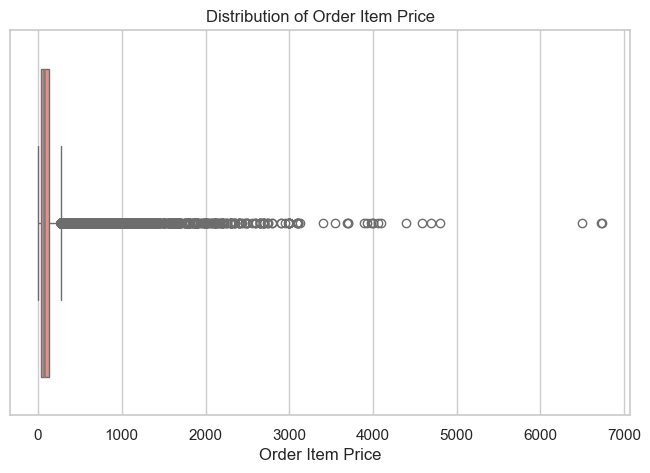

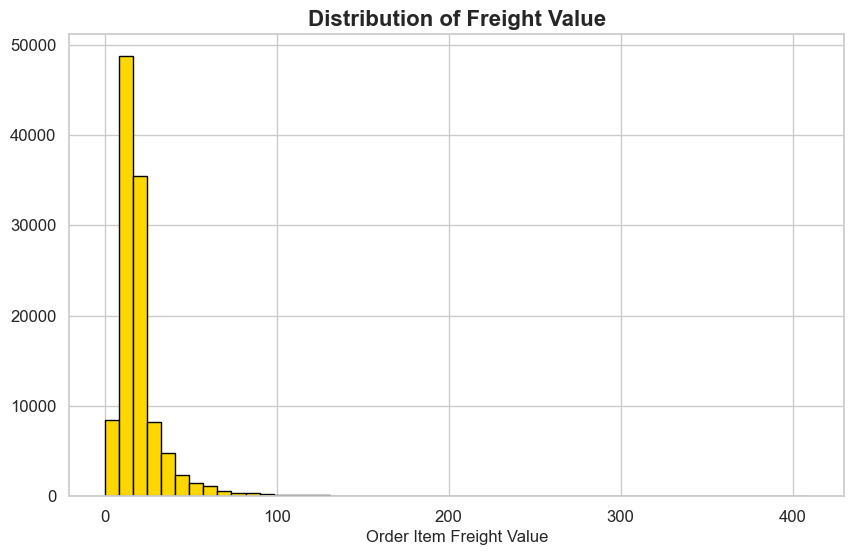

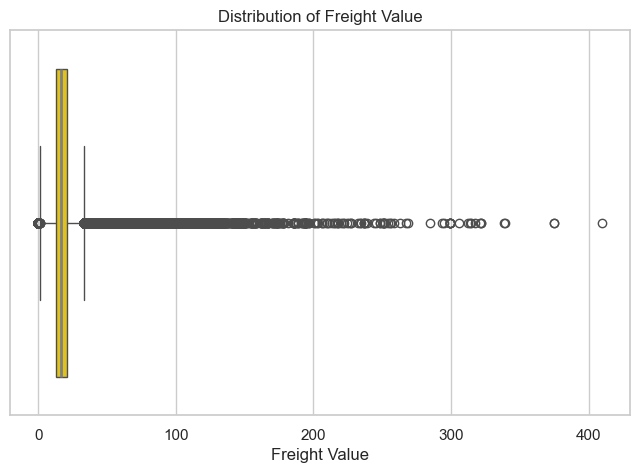

In [299]:
# Order Item Price Distribution
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.hist(order_items['price'], bins=50, color='salmon', edgecolor='black') 
plt.title("Distribution of Order Item Price", fontsize=16, fontweight='bold')
plt.xlabel("Order Item Price")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(x=order_items['price'], color='salmon',
            medianprops=dict(color='gray', linewidth=2))
plt.title("Distribution of Order Item Price")
plt.xlabel("Order Item Price")
plt.show()

# Freight Value Distribution
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
plt.hist(order_items['freight_value'], bins=50, color='gold', edgecolor='black') 
plt.title("Distribution of Freight Value", fontsize=16, fontweight='bold')
plt.xlabel("Order Item Freight Value")
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()

sns.set(style="whitegrid")
plt.figure(figsize=(8,5))
sns.boxplot(x=order_items['freight_value'], color='gold',
            medianprops=dict(color='gray', linewidth=2))
plt.title("Distribution of Freight Value")
plt.xlabel("Freight Value")
plt.show()

Price and Freight per Order Statistics:
       price_per_order  freight_per_order
count     98666.000000       98666.000000
mean        137.754076          22.823562
std         210.645145          21.650909
min           0.850000           0.000000
25%          45.900000          13.850000
50%          86.900000          17.170000
75%         149.900000          24.040000
max       13440.000000        1794.960000


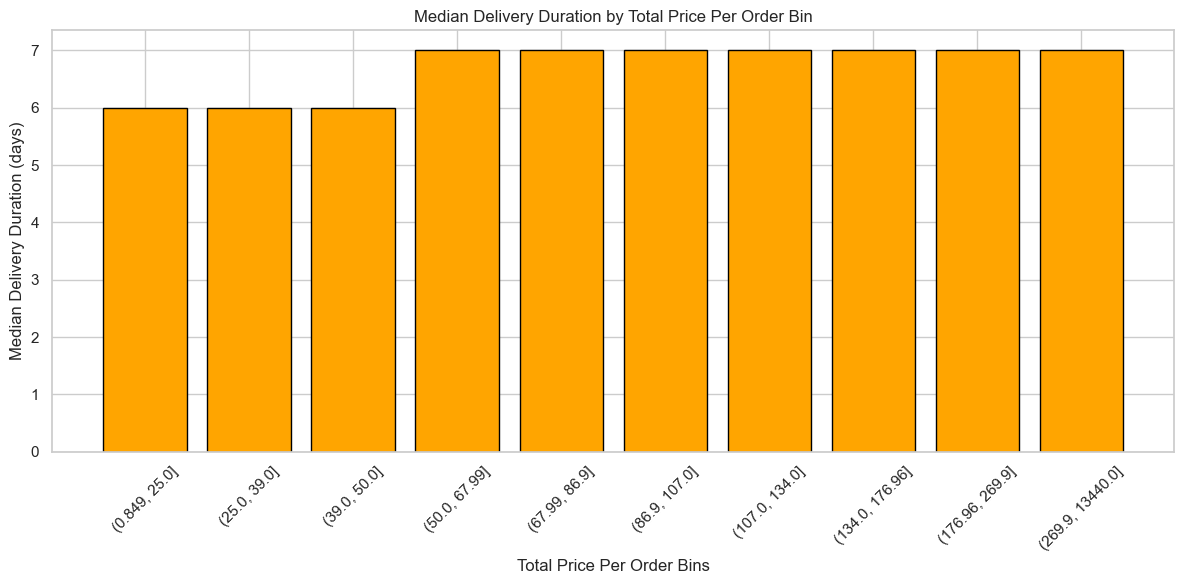

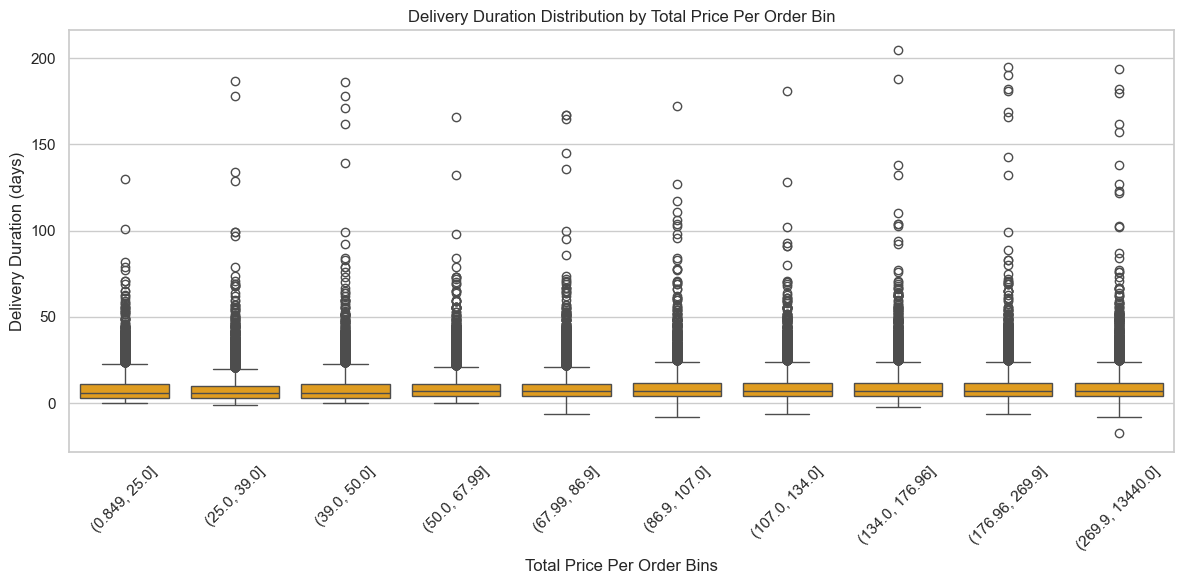

In [300]:
# Total Price and Freight per order
items_agg = order_items.groupby('order_id').agg(
    price_per_order=('price', 'sum'),
    freight_per_order=('freight_value', 'sum'),
).reset_index()

print("Price and Freight per Order Statistics:")
print(items_agg.describe())

# Merge with delivery duration
orders_items_merged = items_agg.merge(
    delivered_orders[['order_id','delivery_duration']], on='order_id', how='left'
)

# Price bins vs delivery duration
orders_items_merged['price_bin'] = pd.qcut(orders_items_merged['price_per_order'], 10)
median_duration = orders_items_merged.groupby('price_bin')['delivery_duration'].median().reset_index()

plt.figure(figsize=(12,6))
plt.bar(range(len(median_duration)), median_duration['delivery_duration'], 
        color='orange', edgecolor='black')
plt.xticks(range(len(median_duration)), median_duration['price_bin'].astype(str), rotation=45)
plt.xlabel("Total Price Per Order Bins")
plt.ylabel("Median Delivery Duration (days)")
plt.title("Median Delivery Duration by Total Price Per Order Bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='price_bin', y='delivery_duration', data=orders_items_merged, color='orange')
plt.xticks(rotation=45)
plt.xlabel("Total Price Per Order Bins")
plt.ylabel("Delivery Duration (days)")
plt.title("Delivery Duration Distribution by Total Price Per Order Bin")
plt.tight_layout()
plt.show()

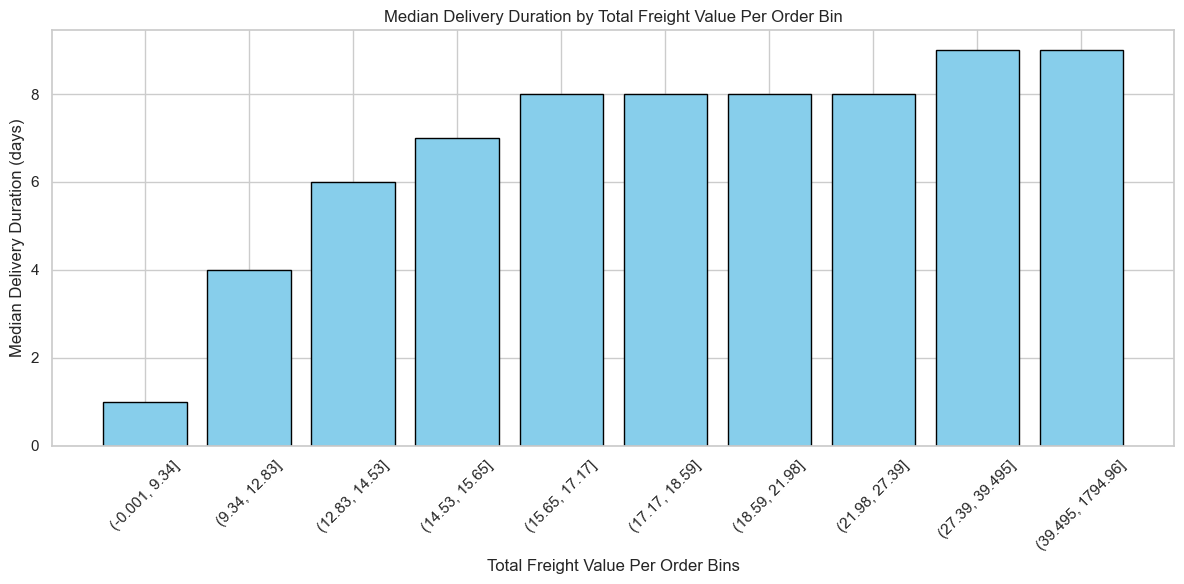

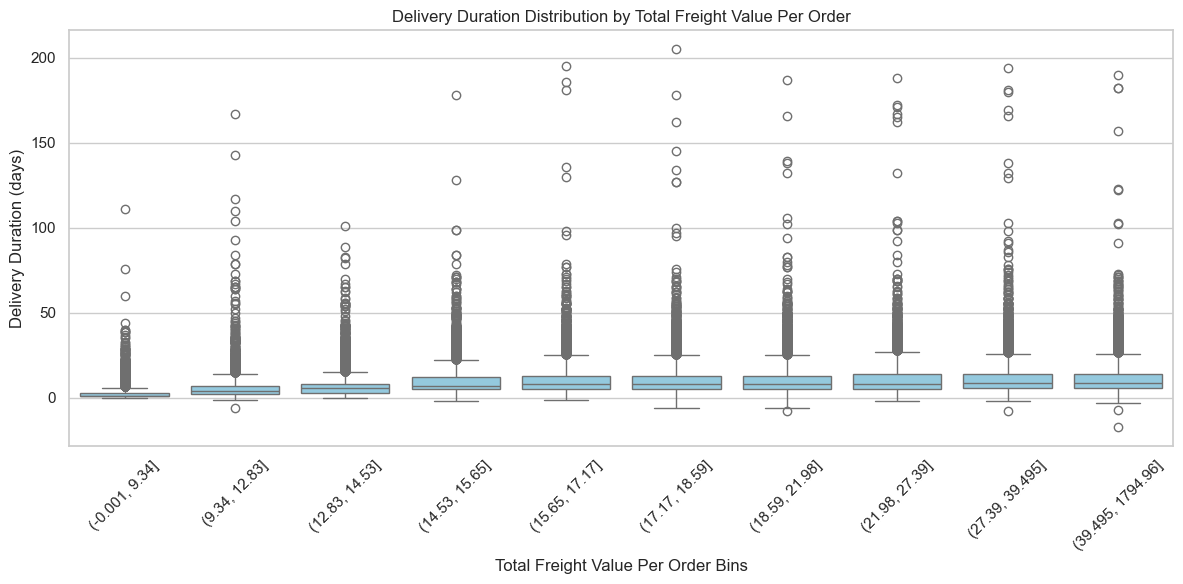

In [301]:
# Freight bins vs delivery duration
orders_items_merged['freight_bin'] = pd.qcut(orders_items_merged['freight_per_order'], 10)
median_duration = orders_items_merged.groupby('freight_bin')['delivery_duration'].median().reset_index()

plt.figure(figsize=(12,6))
plt.bar(range(len(median_duration)), median_duration['delivery_duration'], 
        color='skyblue', edgecolor='black')
plt.xticks(range(len(median_duration)), median_duration['freight_bin'].astype(str), rotation=45)
plt.xlabel("Total Freight Value Per Order Bins")
plt.ylabel("Median Delivery Duration (days)")
plt.title("Median Delivery Duration by Total Freight Value Per Order Bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='freight_bin', y='delivery_duration', data=orders_items_merged, color='skyblue')
plt.xticks(rotation=45)
plt.xlabel("Total Freight Value Per Order Bins")
plt.ylabel("Delivery Duration (days)")
plt.title("Delivery Duration Distribution by Total Freight Value Per Order")
plt.tight_layout()
plt.show()

In [302]:
# Freight ratio analysis
order_items['freight_ratio'] = order_items['freight_value'] / order_items['price']
outliers = order_items[order_items['freight_ratio'] > 1]  # freight cost > product price

print(f"Orders with unusually high freight relative to price: {len(outliers)}")
outliers_ratio = len(outliers) / len(order_items)
print(f"Outlier ratio: {outliers_ratio:.2%}")

print("\nOutlier examples:")
print(outliers[['order_id', 'price', 'freight_value', 'freight_ratio']].head())

Orders with unusually high freight relative to price: 4124
Outlier ratio: 3.66%

Outlier examples:
                             order_id  price  freight_value  freight_ratio
58   0025081dcf9330f9a5052ae82c6ce396  14.95          18.23       1.219398
80   002f98c0f7efd42638ed6100ca699b42   8.99          32.57       3.622914
110  003edccf16bc5ec447f592913b3df2b4  14.00          50.85       3.632143
125  00482f2670787292280e0a8153d82467   7.60          10.96       1.442105
156  00602f25bffa1dcfb71e202fbf9824fb  39.90          54.02       1.353885


In [303]:
### 4.7 Product Analysis

In [304]:
# Product and delivery duration
# Merge order_items with orders and products
orders_items_products = (
    order_items
    .merge(delivered_orders[['order_id','delivery_duration']], on='order_id', how='left')
    .merge(products[['product_id','product_category_name']], on='product_id', how='left')
)

# Add English names
orders_items_products = orders_items_products.merge(
    category_translation, on='product_category_name', how='left'
)

# Filter undelivered orders
orders_items_products = orders_items_products.dropna(subset=['delivery_duration'])
orders_items_products['product_category_name'] = orders_items_products['product_category_name'].fillna('Unknown')
orders_items_products['product_category_name_english'] = orders_items_products['product_category_name_english'].fillna('Unknown')

print(f"✓ Product-order data prepared")
print(f"Missing values:\n{orders_items_products.isna().sum()}")

# Category delivery duration analysis
category_delivery = orders_items_products.groupby('product_category_name_english')['delivery_duration'].mean().sort_values(ascending=False)

print("\nProduct Category Delivery Duration (sorted):")
print(category_delivery)

✓ Product-order data prepared
Missing values:
order_id                         0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
freight_ratio                    0
delivery_duration                0
product_category_name            0
product_category_name_english    0
dtype: int64

Product Category Delivery Duration (sorted):
product_category_name_english
security_and_services                13.000000
christmas_supplies                   11.933333
home_comfort_2                       11.700000
furniture_mattress_and_upholstery    11.189189
home_confort                         10.258741
                                       ...    
diapers_and_hygiene                   6.297297
construction_tools_lights             6.023256
la_cuisine                            5.714286
books_imported                        4.877193
arts_and_c

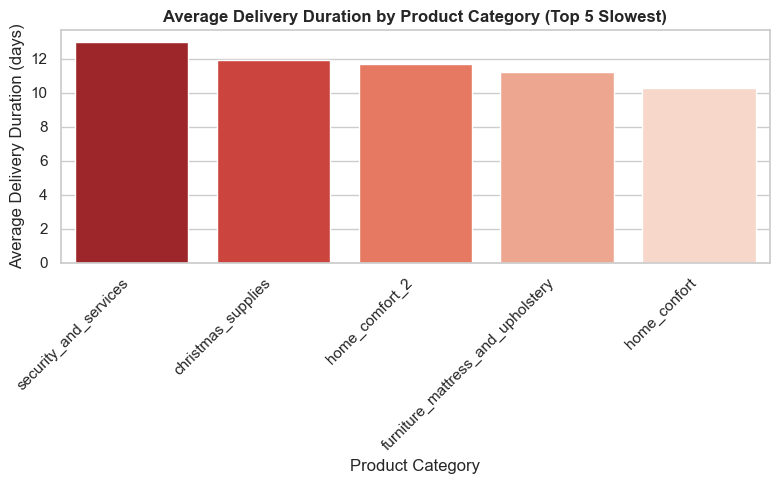

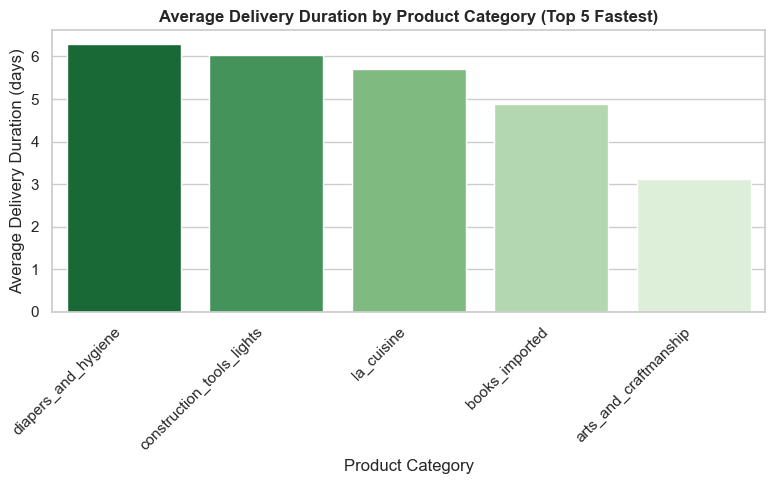

In [305]:
# Top 5 slowest categories
top_5_slowest = category_delivery.head(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_5_slowest.index, y=top_5_slowest.values, palette='Reds_r')
plt.xticks(rotation=45, ha='right')
plt.title("Average Delivery Duration by Product Category (Top 5 Slowest)", fontweight='bold')
plt.ylabel("Average Delivery Duration (days)")
plt.xlabel("Product Category")
plt.tight_layout()
plt.show()

# Top 5 fastest categories
top_5_fastest = category_delivery.tail(5)
plt.figure(figsize=(8,5))
sns.barplot(x=top_5_fastest.index, y=top_5_fastest.values, palette='Greens_r')
plt.xticks(rotation=45, ha='right')
plt.title("Average Delivery Duration by Product Category (Top 5 Fastest)", fontweight='bold')
plt.ylabel("Average Delivery Duration (days)")
plt.xlabel("Product Category")
plt.tight_layout()
plt.show()

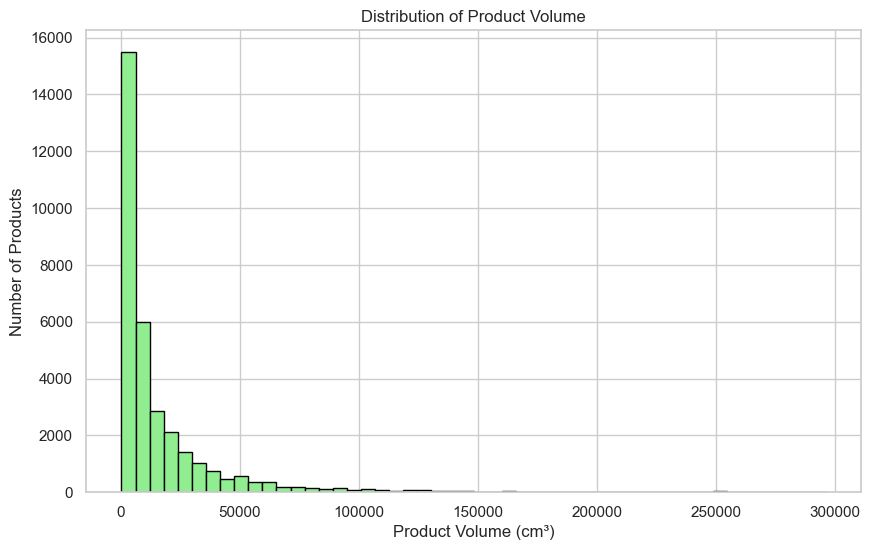


Product summary statistics:
       volume_per_order  weight_per_order
count      9.646900e+04      96469.000000
mean       1.732879e+04       2386.424613
std        3.014223e+04       4769.814911
min        0.000000e+00          0.000000
25%        2.964000e+03        300.000000
50%        7.250000e+03        750.000000
75%        1.986600e+04       2050.000000
max        1.476000e+06     184400.000000


In [306]:
# Product volume calculation
products['product_volume'] = (
    products['product_length_cm'] *
    products['product_height_cm'] *
    products['product_width_cm']
)

plt.figure(figsize=(10,6))
plt.hist(products['product_volume'], bins=50, color='lightgreen', edgecolor='black')
plt.xlabel("Product Volume (cm³)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Volume")
plt.show()

# Merge products with orders
orders_items_products_vol = (
    order_items
    .merge(delivered_orders[['order_id','delivery_duration']], on='order_id', how='left')
    .merge(products[['product_id','product_weight_g','product_volume','product_category_name']], 
           on='product_id', how='left')
)

orders_items_products_vol = orders_items_products_vol.dropna(subset=['delivery_duration'])

# Aggregate by order
product_summary = orders_items_products_vol.groupby('order_id').agg(
    volume_per_order=('product_volume', 'sum'),
    weight_per_order=('product_weight_g', 'sum'),
).reset_index()

print("\nProduct summary statistics:")
print(product_summary.describe())

orders_products_merged = product_summary.merge(
    delivered_orders[['order_id','delivery_duration']], on='order_id', how='left'
)

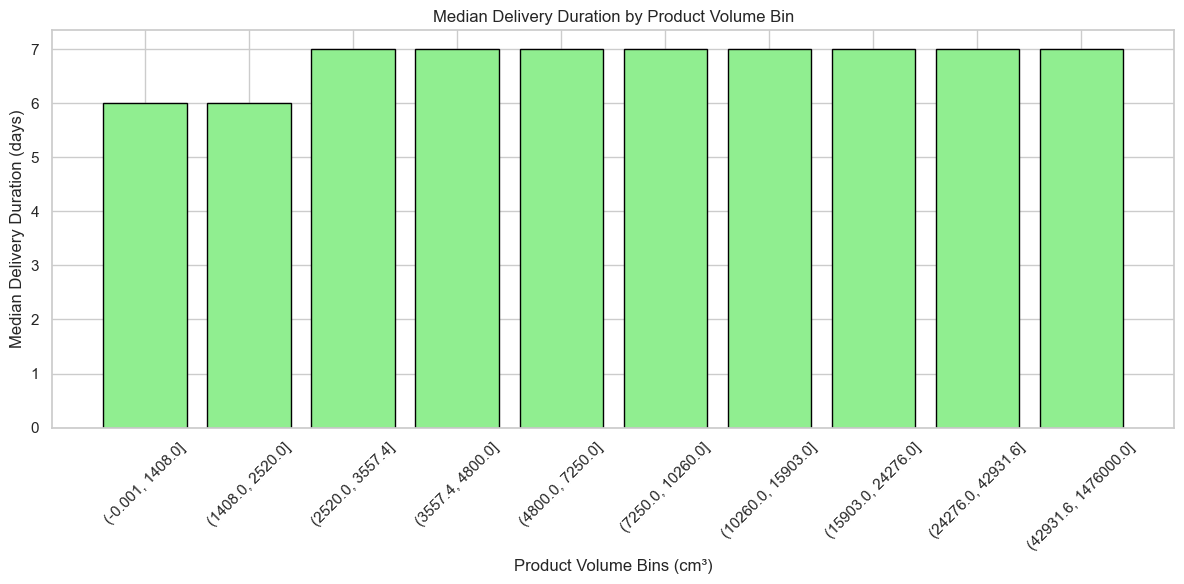

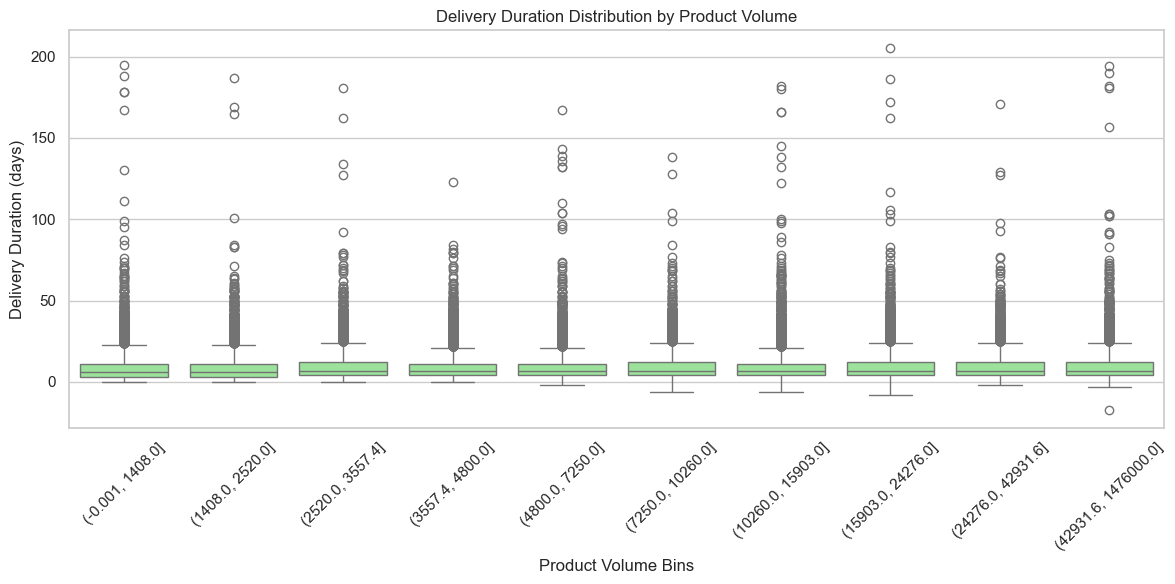

In [307]:
# Median delivery duration per product volume bin
orders_products_merged['volume_bin'] = pd.qcut(orders_products_merged['volume_per_order'], 10)
avg_duration = orders_products_merged.groupby('volume_bin')['delivery_duration'].median().reset_index()

plt.figure(figsize=(12,6))
plt.bar(range(len(avg_duration)), avg_duration['delivery_duration'], 
        color='lightgreen', edgecolor='black')
plt.xticks(range(len(avg_duration)), avg_duration['volume_bin'].astype(str), rotation=45)
plt.xlabel("Product Volume Bins (cm³)")
plt.ylabel("Median Delivery Duration (days)")
plt.title("Median Delivery Duration by Product Volume Bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='volume_bin', y='delivery_duration', data=orders_products_merged, color='lightgreen')
plt.xticks(rotation=45)
plt.xlabel("Product Volume Bins")
plt.ylabel("Delivery Duration (days)")
plt.title("Delivery Duration Distribution by Product Volume")
plt.tight_layout()
plt.show()

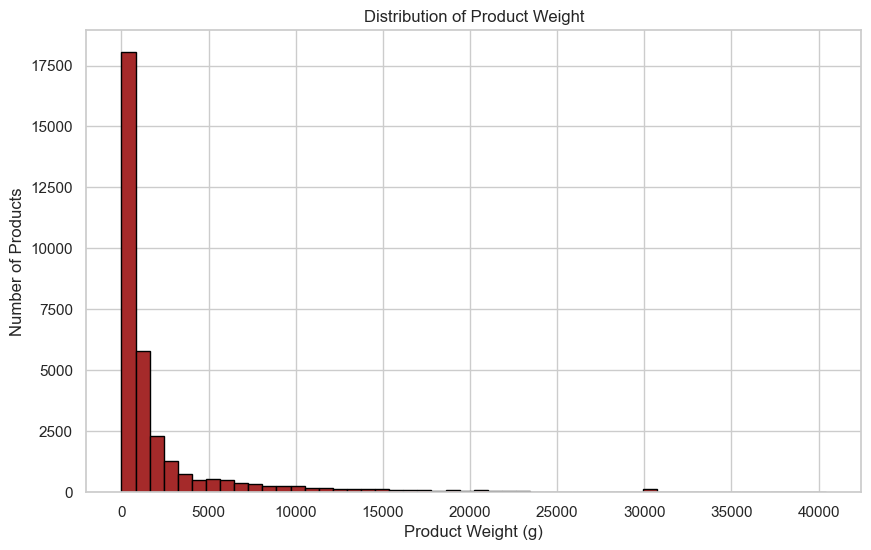

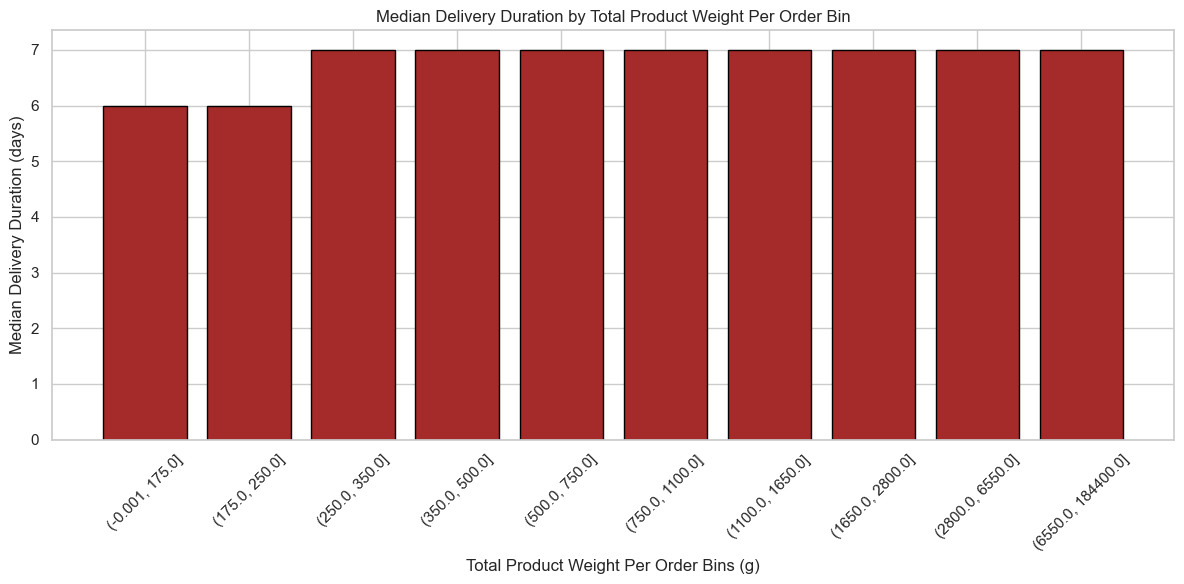

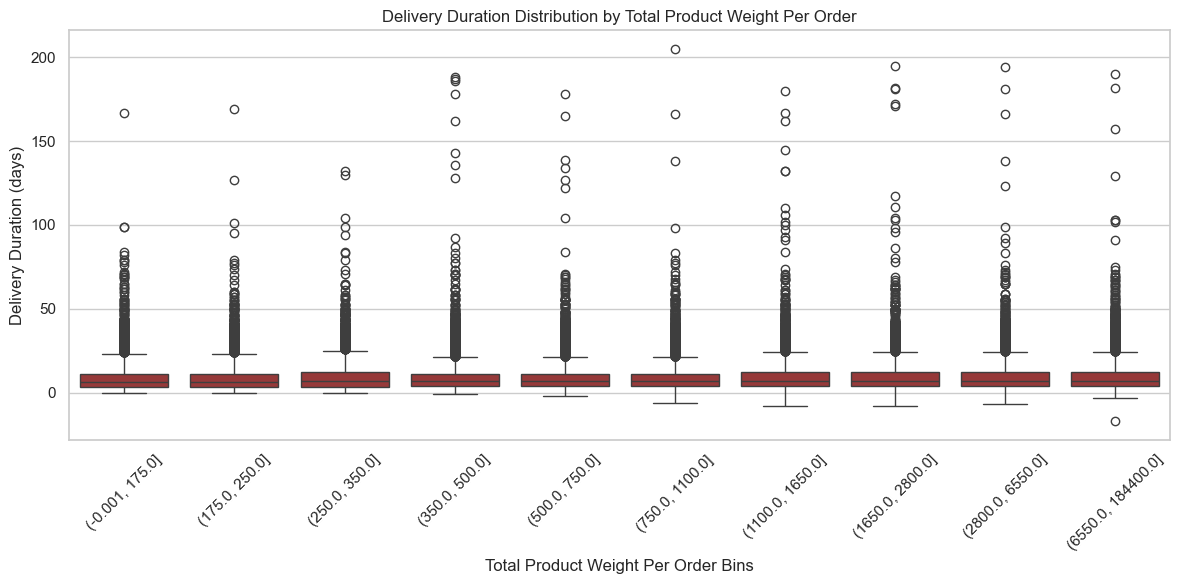

In [308]:
# Product weight analysis
plt.figure(figsize=(10,6))
plt.hist(products['product_weight_g'], bins=50, color='brown', edgecolor='black')
plt.xlabel("Product Weight (g)")
plt.ylabel("Number of Products")
plt.title("Distribution of Product Weight")
plt.show()

# Median delivery duration per product weight bin
orders_products_merged['weight_bin'] = pd.qcut(orders_products_merged['weight_per_order'], 10)
avg_duration = orders_products_merged.groupby('weight_bin')['delivery_duration'].median().reset_index()

plt.figure(figsize=(12,6))
plt.bar(range(len(avg_duration)), avg_duration['delivery_duration'], 
        color='brown', edgecolor='black')
plt.xticks(range(len(avg_duration)), avg_duration['weight_bin'].astype(str), rotation=45)
plt.xlabel("Total Product Weight Per Order Bins (g)")
plt.ylabel("Median Delivery Duration (days)")
plt.title("Median Delivery Duration by Total Product Weight Per Order Bin")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(x='weight_bin', y='delivery_duration', data=orders_products_merged, color='brown')
plt.xticks(rotation=45)
plt.xlabel("Total Product Weight Per Order Bins")
plt.ylabel("Delivery Duration (days)")
plt.title("Delivery Duration Distribution by Total Product Weight Per Order")
plt.tight_layout()
plt.show()

In [309]:
### 4.8 Order Reviews Analysis

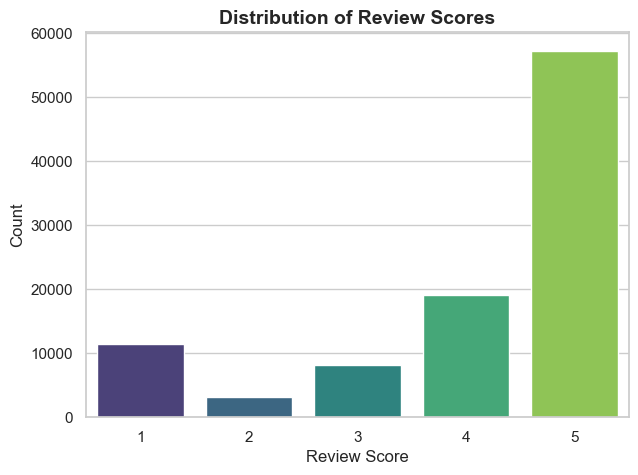

Review Score Distribution:
review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


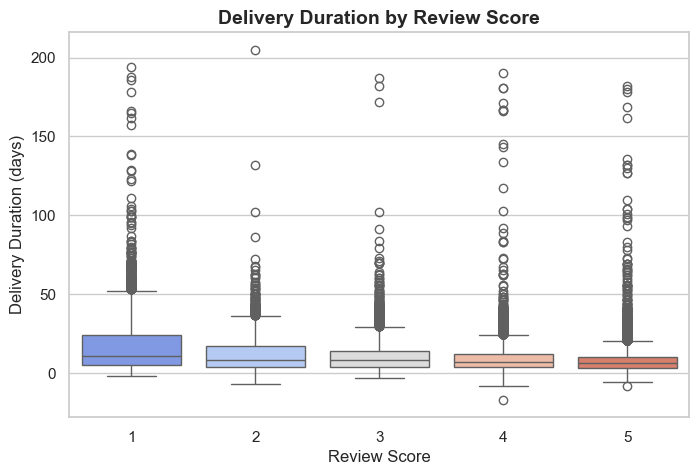


Average Delivery Duration by Review Score:
review_score
1    16.113663
2    12.145189
3    10.209270
4     8.632222
5     7.361141
Name: delivery_duration, dtype: float64


In [310]:
# Review score distribution
plt.figure(figsize=(7,5))
sns.countplot(data=order_reviews, x='review_score', palette='viridis')
plt.title('Distribution of Review Scores', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.show()

print("Review Score Distribution:")
print(order_reviews['review_score'].value_counts().sort_index())

# Delivery duration by review score
order_reviews['review_score'] = order_reviews['review_score'].astype(int)
reviews_duration = order_reviews.merge(
    delivered_orders[['order_id', 'delivery_duration']], on='order_id', how='inner'
)

plt.figure(figsize=(8,5))
sns.boxplot(data=reviews_duration, x='review_score', y='delivery_duration', palette='coolwarm')
plt.title('Delivery Duration by Review Score', fontsize=14, fontweight='bold')
plt.xlabel('Review Score')
plt.ylabel('Delivery Duration (days)')
plt.show()

# Average delivery duration by review score
avg_duration_by_score = reviews_duration.groupby('review_score')['delivery_duration'].mean()
print("\nAverage Delivery Duration by Review Score:")
print(avg_duration_by_score)

### 4.9 Correlation Matrix Analysis

Analyzing 9 features (including target)
EDA Numeric Predictors: 8
Features: ['delivery_duration', 'delay_days', 'price_per_order', 'freight_per_order', 'num_items', 'order_total', 'payment_installments', 'product_weight_g', 'product_volume']

CORRELATION WITH TARGET (DELIVERY_DURATION)
delivery_duration       1.000000
delay_days              0.581259
freight_per_order       0.143821
payment_installments    0.056551
order_total             0.042677
product_weight_g        0.031441
price_per_order         0.029801
product_volume          0.023220
num_items              -0.034977
Name: delivery_duration, dtype: float64



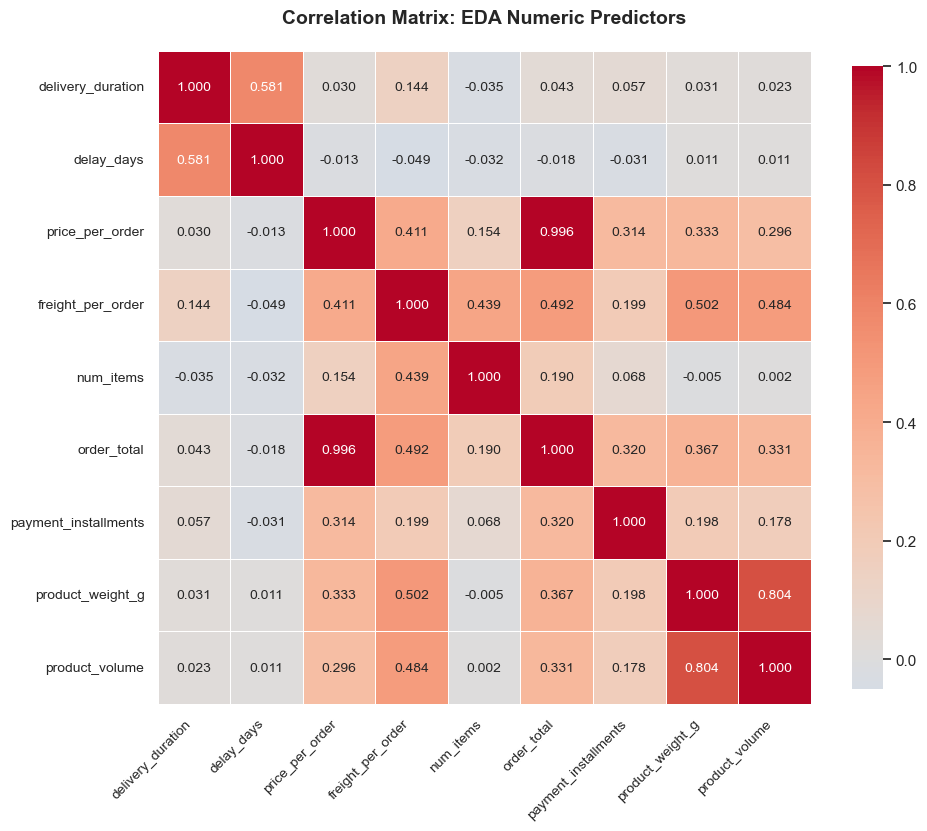

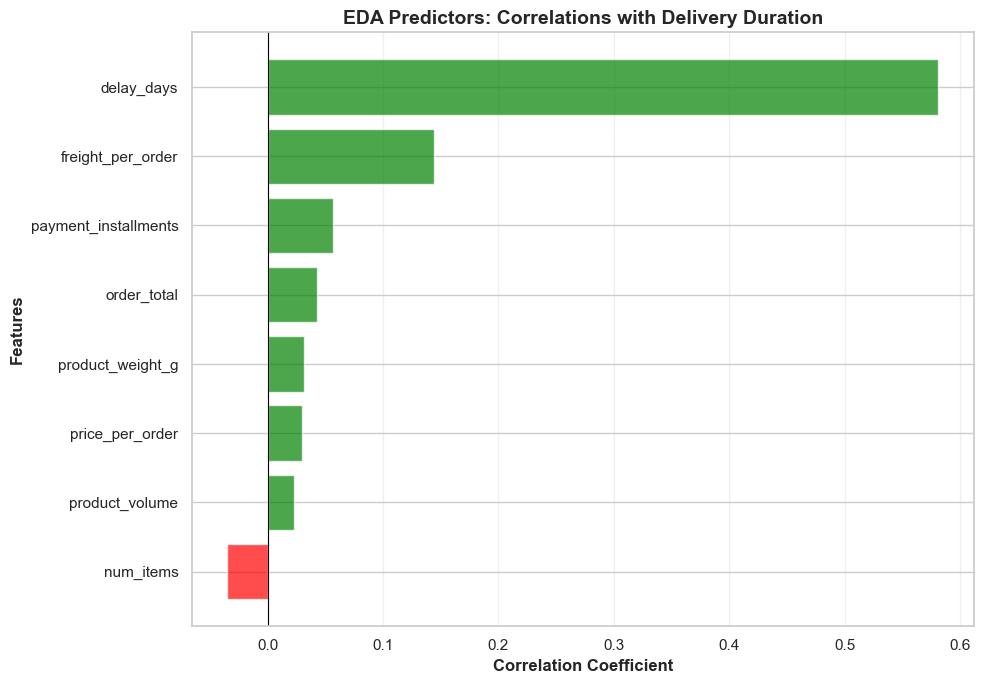


✓ Correlation analysis complete
Total EDA predictors: 8
Dataset size: 96,452 orders


In [311]:
# Create a combined dataset for correlation analysis
# Use only numeric predictors available during EDA (before Feature Engineering)
corr_data = delivered_orders[['order_id', 'delivery_duration', 'delay_days']].copy()

# Merge with order items aggregations (from EDA 4.6: items_agg)
corr_data = corr_data.merge(items_agg[['order_id', 'price_per_order', 'freight_per_order']], on='order_id', how='left')

# Add number of items per order (from EDA 4.6)
order_item_counts = order_items.groupby('order_id')['order_item_id'].count().reset_index()
order_item_counts.columns = ['order_id', 'num_items']
corr_data = corr_data.merge(order_item_counts, on='order_id', how='left')

# Merge with payment aggregations (from EDA 4.5: orders_payment_summary)
corr_data = corr_data.merge(orders_payment_summary[['order_id', 'order_total', 'payment_installments']], on='order_id', how='left')

# Merge with product features (from EDA 4.7)
# Calculate product volume and weight at order level
products_with_volume = products.copy()
products_with_volume['product_volume'] = (
    products_with_volume['product_length_cm'] * 
    products_with_volume['product_height_cm'] * 
    products_with_volume['product_width_cm']
)

order_items_products_temp = order_items.merge(
    products_with_volume[['product_id', 'product_weight_g', 'product_volume']], 
    on='product_id', how='left'
)

product_agg = order_items_products_temp.groupby('order_id').agg({
    'product_weight_g': 'mean',
    'product_volume': 'mean'
}).reset_index()

corr_data = corr_data.merge(product_agg, on='order_id', how='left')

# Drop order_id for correlation analysis
corr_data = corr_data.drop(columns=['order_id'])

# Select only numeric predictors from EDA sections (before Feature Engineering)
numeric_cols = [
    'delivery_duration',       # Target variable
    'delay_days',             # On-time vs delayed (EDA 4.2)
    'price_per_order',        # Order items: total price (EDA 4.6)
    'freight_per_order',      # Order items: total freight (EDA 4.6)
    'num_items',              # Order items: item count (EDA 4.6)
    'order_total',            # Payment: total payment (EDA 4.5)
    'payment_installments',   # Payment: installments (EDA 4.5)
    'product_weight_g',       # Product: average weight (EDA 4.7)
    'product_volume'          # Product: average volume (EDA 4.7)
]

# Filter to only include columns that exist
numeric_cols = [col for col in numeric_cols if col in corr_data.columns]

corr_subset = corr_data[numeric_cols].dropna()

print(f"Analyzing {len(numeric_cols)} features (including target)")
print(f"EDA Numeric Predictors: {len(numeric_cols) - 1}")
print(f"Features: {numeric_cols}")

# Calculate correlation matrix
correlation_matrix = corr_subset.corr()

print("\n" + "="*80)
print("CORRELATION WITH TARGET (DELIVERY_DURATION)")
print("="*80)
corr_with_target = correlation_matrix['delivery_duration'].sort_values(ascending=False)
print(corr_with_target)
print()

# Visualize correlation matrix
plt.figure(figsize=(10, 9))
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8},
            annot_kws={'size': 10})
plt.title('Correlation Matrix: EDA Numeric Predictors', 
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Visualize correlations with target as bar plot
plt.figure(figsize=(10, 7))
corr_with_target_sorted = corr_with_target.drop('delivery_duration').sort_values()
colors = ['red' if x < 0 else 'green' for x in corr_with_target_sorted.values]
plt.barh(corr_with_target_sorted.index, corr_with_target_sorted.values, color=colors, alpha=0.7)
plt.xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('EDA Predictors: Correlations with Delivery Duration', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✓ Correlation analysis complete")
print(f"Total EDA predictors: {len(corr_with_target) - 1}")
print(f"Dataset size: {len(corr_subset):,} orders")

---
## 5. Feature Engineering

### 5.1 Order Features

Creating features for:
- Temporal features (purchase month, weekend indicators)
- Delivery metrics

In [312]:
# Use delivered_orders for training
delivered_orders['order_purchase_timestamp'] = pd.to_datetime(delivered_orders['order_purchase_timestamp'])
delivered_orders['order_delivered_carrier_date'] = pd.to_datetime(delivered_orders['order_delivered_carrier_date'])

# Day/month of purchase (affects when order enters system)
delivered_orders['purchase_month'] = delivered_orders['order_purchase_timestamp'].dt.month
delivered_orders['purchase_weekday'] = delivered_orders['order_purchase_timestamp'].dt.weekday
delivered_orders['purcharse_is_weekend'] = delivered_orders['purchase_weekday'].isin([5,6]).astype(int)

# Day/month of delivery (affects carrier delays)
delivered_orders['carrier_month'] = delivered_orders['order_delivered_carrier_date'].dt.month
delivered_orders['carrier_weekday'] = delivered_orders['order_delivered_carrier_date'].dt.weekday
delivered_orders['delivery_is_weekend'] = delivered_orders['carrier_weekday'].isin([5,6]).astype(int)

# Create clean orders dataset
orders_clean = delivered_orders[[
    'order_id', 'customer_id', 'purchase_month', 'purcharse_is_weekend', 
    'carrier_month', 'delivery_is_weekend', 'delivery_duration'
]]

print("✓ Order features created")
orders_clean.head()

✓ Order features created


,order_id,customer_id,purchase_month,purcharse_is_weekend,carrier_month,delivery_is_weekend,delivery_duration
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,10,0,10.0,0,6.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,7,0,7.0,0,12.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,8,0,8.0,0,9.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,11,1,11.0,0,9.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2,0,2.0,0,1.0


### 5.2 Customer Features

Creating features for:
- Customer location (state, city, lat/lng)

In [313]:
# Encode customer location
le = LabelEncoder()
customers['customer_state_encoded'] = le.fit_transform(customers['customer_state'].astype(str))
customers['customer_city_encoded'] = le.fit_transform(customers['customer_city'].astype(str))

# Convert prefix to lat and lng
customers['customer_zip_code_prefix'] = customers['customer_zip_code_prefix'].astype(str)
geolocation['geolocation_zip_code_prefix'] = geolocation['geolocation_zip_code_prefix'].astype(str)
geo_agg = geolocation.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].median().reset_index()

customers_clean = pd.merge(customers, geo_agg, 
                           left_on='customer_zip_code_prefix', 
                           right_on='geolocation_zip_code_prefix', 
                           how='left')

customers_clean = customers_clean.drop(columns=[
    'customer_unique_id', 'customer_zip_code_prefix', 
    'geolocation_zip_code_prefix', 'customer_state', 'customer_city'
])

print("✓ Customer features created")
customers_clean.head()

✓ Customer features created


,customer_id,customer_state_encoded,customer_city_encoded,geolocation_lat,geolocation_lng
0,06b8999e2fba1a1fbc88172c00ba8bc7,25,1382,-20.502070,-47.396822
1,18955e83d337fd6b2def6b18a428ac77,25,3428,-23.727299,-46.542631
2,4e7b3e00288586ebd08712fdd0374a03,25,3597,-23.531294,-46.656404
3,b2b6027bc5c5109e529d4dc6358b12c3,25,2341,-23.497390,-46.182342
4,4f2d8ab171c80ec8364f7c12e35b23ad,25,707,-22.973309,-47.141530


### 5.3 Seller Features

Creating features for:
- Seller location (state, city, lat/lng)

In [314]:
# Encode seller location
sellers['seller_state_encoded'] = le.fit_transform(sellers['seller_state'].astype(str))
sellers['seller_city_encoded'] = le.fit_transform(sellers['seller_city'].astype(str))

# Convert prefix to lat and lng
sellers['seller_zip_code_prefix'] = sellers['seller_zip_code_prefix'].astype(str)
sellers_clean = pd.merge(sellers, geo_agg, 
                         left_on='seller_zip_code_prefix', 
                         right_on='geolocation_zip_code_prefix', 
                         how='left')

sellers_clean = sellers_clean.drop(columns=[
    'seller_zip_code_prefix', 'geolocation_zip_code_prefix', 
    'seller_state', 'seller_city'
])

print("✓ Seller features created")
sellers_clean.head()

✓ Seller features created


,seller_id,seller_state_encoded,seller_city_encoded,geolocation_lat,geolocation_lng
0,3442f8959a84dea7ee197c632cb2df15,22,101,-22.894561,-47.062380
1,d1b65fc7debc3361ea86b5f14c68d2e2,22,342,-22.382440,-46.947605
2,ce3ad9de960102d0677a81f5d0bb7b2d,16,450,-22.909624,-43.176774
3,c0f3eea2e14555b6faeea3dd58c1b1c3,22,517,-23.657453,-46.612406
4,51a04a8a6bdcb23deccc82b0b80742cf,22,80,-22.964436,-46.535090


### 5.4 Distance Calculation

Merging customer and seller locations at order level to calculate distance

In [315]:
# Merge customers and sellers at order level
orders_customers = delivered_orders[['order_id', 'customer_id']].merge(
    customers_clean, on='customer_id', how='left'
)
orders_customers.rename(columns={
    'geolocation_lat': 'customer_lat',
    'geolocation_lng': 'customer_lng'
}, inplace=True)

orders_sellers = order_items[['order_id', 'seller_id']].merge(
    sellers_clean, on='seller_id', how='left'
)
orders_sellers.rename(columns={
    'geolocation_lat': 'seller_lat',
    'geolocation_lng': 'seller_lng'
}, inplace=True)

order_geo = orders_customers.merge(orders_sellers, on='order_id', how='left')

# Calculate distance using Haversine formula
def haversine(lat1, lon1, lat2, lon2):
    # Convert degrees to radians
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    km = 6371 * c  # Radius of Earth in km
    return km

order_geo['distance_km'] = haversine(
    order_geo['customer_lat'], order_geo['customer_lng'],
    order_geo['seller_lat'], order_geo['seller_lng']
)

order_geo = order_geo.drop(columns=[
    'customer_id', 'customer_lat', 'customer_lng', 
    'seller_id', 'seller_lat', 'seller_lng'
])

print("✓ Distance calculated")
order_geo.head()

✓ Distance calculated


,order_id,customer_state_encoded,customer_city_encoded,seller_state_encoded,seller_city_encoded,distance_km
0,e481f51cbdc54678b7cc49136f2d6af7,25,3597,22,328,18.681711
1,53cdb2fc8bc7dce0b6741e2150273451,4,418,22,64,861.035367
2,47770eb9100c2d0c44946d9cf07ec65d,8,4050,22,218,514.547140
3,949d5b44dbf5de918fe9c16f97b45f8a,19,3473,8,64,1821.802656
4,ad21c59c0840e6cb83a9ceb5573f8159,25,3375,22,340,29.593095


In [316]:
# Aggregate distance and location features at order level
order_distance = order_geo.groupby('order_id')['distance_km'].agg(['mean']).reset_index()
order_distance.rename(columns={'mean': 'mean_distance_km'}, inplace=True)

def get_mode(series):
    return series.mode()[0] if not series.mode().empty else np.nan

region_features = order_geo.groupby('order_id').agg({
    'customer_state_encoded': get_mode,
    'seller_state_encoded': get_mode,
    'customer_city_encoded': get_mode,
    'seller_city_encoded': get_mode
}).reset_index()

order_location = order_distance.merge(region_features, on='order_id', how='left')

print("✓ Order location features aggregated")
order_location.head()

✓ Order location features aggregated


,order_id,mean_distance_km,customer_state_encoded,seller_state_encoded,customer_city_encoded,seller_city_encoded
0,00010242fe8c5a6d1ba2dd792cb16214,301.229205,18,22,740,606
1,00018f77f2f0320c557190d7a144bdd3,588.404069,25,22,3288,517
2,000229ec398224ef6ca0657da4fc703e,312.835023,10,8,2665,77
3,00024acbcdf0a6daa1e931b038114c75,295.032480,25,22,330,196
4,00042b26cf59d7ce69dfabb4e55b4fd9,646.468544,25,15,4026,304


### 5.5 Payment Features

Aggregating payment data at order level:
- Total payment value
- Maximum installments
- Payment type (one-hot encoded)

In [317]:
# Total payment value per order
order_total = order_payments.groupby('order_id')['payment_value'].sum().reset_index()
order_total.rename(columns={'payment_value': 'total_order_payment'}, inplace=True)

# Maximum installments per order
order_installments = order_payments.groupby('order_id')['payment_installments'].max().reset_index()

# Payment type (mode) - one-hot encode
payment_type_mode = order_payments.groupby('order_id')['payment_type'].agg(
    lambda x: x.mode()[0]
).reset_index()

payment_type_dummies = pd.get_dummies(payment_type_mode['payment_type'], prefix='payment')
payment_type_dummies['order_id'] = payment_type_mode['order_id']

# Merge all payment features
order_payments_clean = order_total.merge(order_installments, on='order_id', how='left')
order_payments_clean = order_payments_clean.merge(payment_type_dummies, on='order_id', how='left')

print("✓ Payment features created")
order_payments_clean.head()

✓ Payment features created


,order_id,total_order_payment,payment_installments,payment_boleto,payment_credit_card,payment_debit_card,payment_not_defined,payment_voucher
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,False,True,False,False,False
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,False,True,False,False,False
2,000229ec398224ef6ca0657da4fc703e,216.87,5,False,True,False,False,False
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,False,True,False,False,False
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,False,True,False,False,False


### 5.6 Order Items Features

Aggregating order item data at order level:
- Total price
- Total freight
- Number of items

In [318]:
# Remove freight_ratio if it exists (created during EDA)
if 'freight_ratio' in order_items.columns:
    order_items_features = order_items.drop(columns=['shipping_limit_date', 'freight_ratio'])
else:
    order_items_features = order_items.drop(columns=['shipping_limit_date'])

# Aggregate numerical features per order
order_items_clean = order_items_features.groupby('order_id').agg({
    'price': ['sum'],
    'freight_value': ['sum'],
    'order_item_id': 'count'
}).reset_index()

order_items_clean.columns = ['order_id', 'total_price', 'total_freight', 'num_items']

print("✓ Order items features created")
order_items_clean.head()

✓ Order items features created


,order_id,total_price,total_freight,num_items
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,1
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,1
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,1
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,1


### 5.7 Product Features

Creating product features:
- Product weight
- Product volume
- Product category (encoded)

In [319]:
# Create product features
products_features = products[[
    'product_id', 'product_category_name', 'product_weight_g', 
    'product_length_cm', 'product_height_cm', 'product_width_cm'
]].copy()

# Unit conversion: Convert weight from grams to kilograms
products_features['product_weight_kg'] = products_features['product_weight_g'] / 1000.0

# Calculate product volume
products_features['product_volume'] = (
    products_features['product_length_cm'] *
    products_features['product_height_cm'] *
    products_features['product_width_cm']
)

# Merge with category translation
products_clean = products_features.merge(
    category_translation, on='product_category_name', how='left'
)

# Encode category name
le = LabelEncoder()
products_clean['product_category_encoded'] = le.fit_transform(
    products_clean['product_category_name_english'].astype(str)
)

products_clean = products_clean.drop(columns=[
    'product_length_cm', 'product_height_cm', 'product_width_cm', 
    'product_category_name_english', 'product_weight_g'
])

# Convert to order level
order_items_products = order_items.merge(products_clean, on='product_id', how='left')

# Aggregate on order_id
order_products_clean = order_items_products.groupby('order_id').agg({
    'product_weight_kg': 'mean',  # average weight per order in kg
    'product_volume': 'mean',    # average volume per order
    'product_category_encoded': lambda x: x.mode()[0] if not x.mode().empty else np.nan
}).reset_index()

order_products_clean.head()
print("✓ Product features created")

✓ Product features created


### 5.8 Final Dataset Integration

Merging all feature sets into one final dataset

In [320]:
# Integrate all features
final_df = orders_clean.copy()
final_df = final_df.merge(order_location, on='order_id', how='left')
final_df = final_df.merge(order_items_clean, on='order_id', how='left')
final_df = final_df.merge(order_payments_clean, on='order_id', how='left')
final_df = final_df.merge(order_products_clean, on='order_id', how='left')

# Drop order_id and customer_id as they are not predictive
final_df = final_df.drop(columns=['order_id', 'customer_id'])

print("✓ Final dataset created")
print(f"Shape: {final_df.shape}")
print(f"\nColumns: {list(final_df.columns)}")
final_df.head()

✓ Final dataset created
Shape: (96478, 23)

Columns: ['purchase_month', 'purcharse_is_weekend', 'carrier_month', 'delivery_is_weekend', 'delivery_duration', 'mean_distance_km', 'customer_state_encoded', 'seller_state_encoded', 'customer_city_encoded', 'seller_city_encoded', 'total_price', 'total_freight', 'num_items', 'total_order_payment', 'payment_installments', 'payment_boleto', 'payment_credit_card', 'payment_debit_card', 'payment_not_defined', 'payment_voucher', 'product_weight_kg', 'product_volume', 'product_category_encoded']


,purchase_month,purcharse_is_weekend,carrier_month,delivery_is_weekend,delivery_duration,mean_distance_km,customer_state_encoded,seller_state_encoded,customer_city_encoded,seller_city_encoded,...,total_order_payment,payment_installments,payment_boleto,payment_credit_card,payment_debit_card,payment_not_defined,payment_voucher,product_weight_kg,product_volume,product_category_encoded
0,10,0,10.0,0,6.0,18.681711,25,22,3597,328,...,38.71,1.0,False,False,False,False,True,0.50,1976.0,49
1,7,0,7.0,0,12.0,861.035367,4,22,418,64,...,141.46,1.0,True,False,False,False,False,0.40,4693.0,60
2,8,0,8.0,0,9.0,514.547140,8,22,4050,218,...,179.12,3.0,False,True,False,False,False,0.42,9576.0,5
3,11,1,11.0,0,9.0,1821.802656,19,8,3473,64,...,72.20,1.0,False,True,False,False,False,0.45,6000.0,61
4,2,0,2.0,0,1.0,29.593095,25,22,3375,340,...,28.62,1.0,False,True,False,False,False,0.25,11475.0,67


### 5.9 Handle Missing Values

In [321]:
# Check missing values
final_df = final_df.dropna(subset=['delivery_duration'])

print("Shape after dropping rows without delivery_duration:", final_df.shape)
print("Any missing delivery_duration?", final_df['delivery_duration'].isna().any())

missing_values = final_df.isna().sum().sort_values(ascending=False)
print("\nMissing values per column:")
print(missing_values[missing_values > 0])

missing_percentage = (final_df.isna().mean() * 100).sort_values(ascending=False)
print("\nMissing values percentage per column:")
print(missing_percentage[missing_percentage > 0])

# Fill missing numerical values with median
num_cols = ['mean_distance_km', 'product_volume', 'product_weight_kg', 
            'total_order_payment', 'payment_installments']
for col in num_cols:
    if col in final_df.columns and final_df[col].isna().any():
        final_df[col] = final_df[col].fillna(final_df[col].median())

# Fill missing payment type dummies with 0
cate_cols = ['payment_voucher', 'payment_not_defined', 'payment_debit_card', 
             'payment_credit_card', 'payment_boleto']
for col in cate_cols:
    if col in final_df.columns:
        final_df[col] = final_df[col].fillna(0)

missing_percentage_after = (final_df.isna().mean() * 100).sort_values(ascending=False)
print("\n✓ Missing values handled")
print("\nRemaining missing values percentage:")
print(missing_percentage_after[missing_percentage_after > 0])

Shape after dropping rows without delivery_duration: (96469, 23)
Any missing delivery_duration? False

Missing values per column:
mean_distance_km        476
product_volume           16
product_weight_kg        16
payment_voucher           1
payment_not_defined       1
payment_debit_card        1
payment_credit_card       1
payment_boleto            1
payment_installments      1
total_order_payment       1
dtype: int64

Missing values percentage per column:
mean_distance_km        0.493423
product_volume          0.016586
product_weight_kg       0.016586
payment_voucher         0.001037
payment_not_defined     0.001037
payment_debit_card      0.001037
payment_credit_card     0.001037
payment_boleto          0.001037
payment_installments    0.001037
total_order_payment     0.001037
dtype: float64

✓ Missing values handled

Remaining missing values percentage:
Series([], dtype: float64)


### 5.10 Mutual Information Analysis

Mutual Information measures the dependency between features and the target variable. Unlike correlation, it can capture non-linear relationships.

Calculating mutual information scores...
Features: 22, Samples: 96469

TOP 20 FEATURES BY MUTUAL INFORMATION WITH TARGET
                 Feature  MI_Score
        mean_distance_km  0.297391
           total_freight  0.211307
  customer_state_encoded  0.197038
   customer_city_encoded  0.195587
     total_order_payment  0.084890
     seller_city_encoded  0.058778
          purchase_month  0.046859
           carrier_month  0.045478
          product_volume  0.028979
    seller_state_encoded  0.017197
             total_price  0.013680
       product_weight_kg  0.013454
product_category_encoded  0.008937
     delivery_is_weekend  0.008122
    purcharse_is_weekend  0.005650
    payment_installments  0.001471
     payment_not_defined  0.001210
      payment_debit_card  0.000969
               num_items  0.000545
          payment_boleto  0.000454



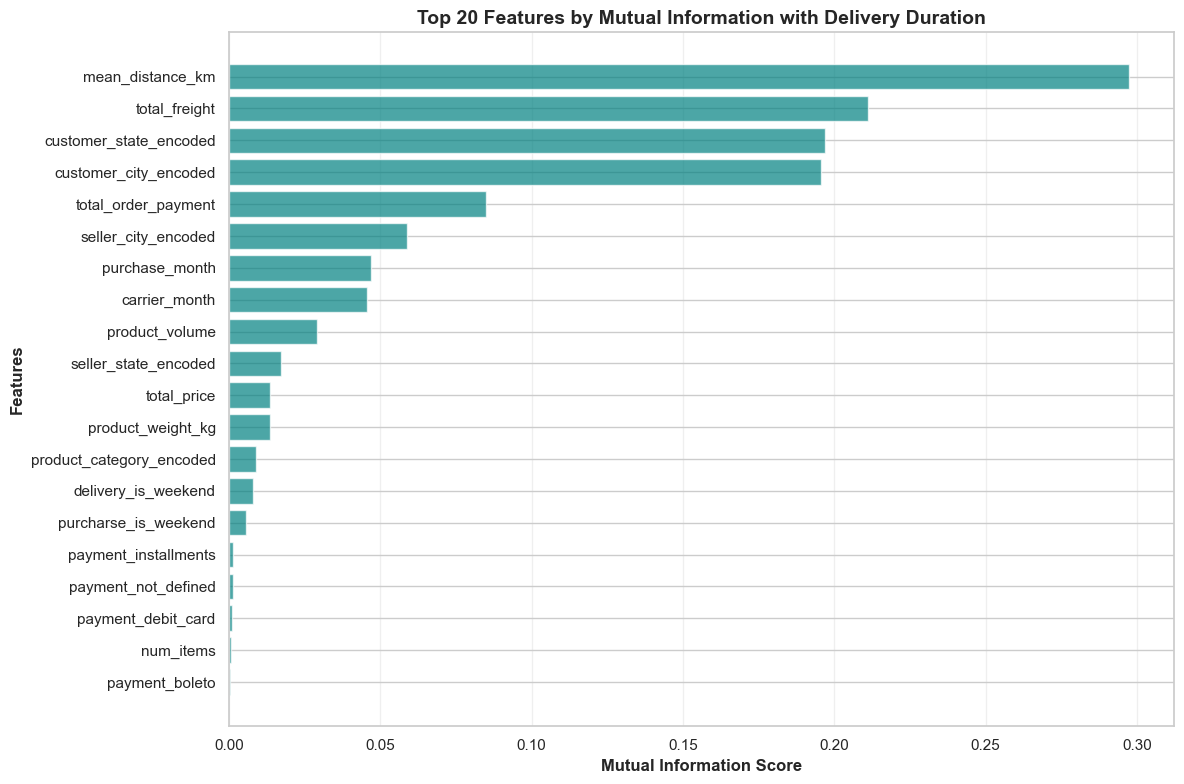

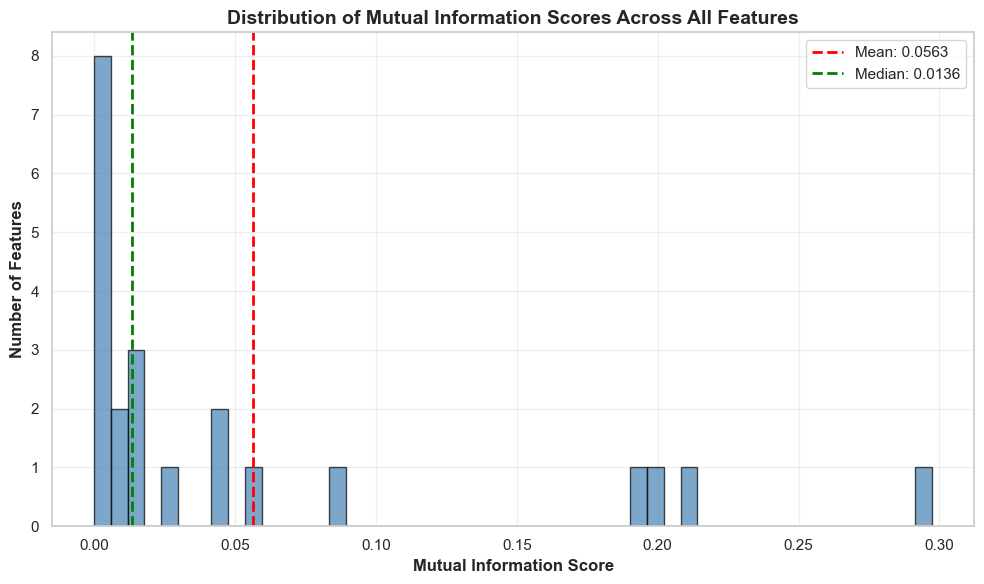


Mutual Information Statistics:
  Mean MI Score: 0.0563
  Median MI Score: 0.0136
  Max MI Score: 0.2974
  Min MI Score: 0.0000
  Features with MI > 0.01: 12
  Features with MI > 0.05: 6
  Features with MI > 0.1: 4

✓ Mutual information analysis complete


In [322]:
from sklearn.feature_selection import mutual_info_regression

# Prepare data for mutual information calculation
X_mi = final_df.drop(columns=['delivery_duration']).fillna(0)
y_mi = final_df['delivery_duration']

# Remove any remaining inf values
X_mi = X_mi.replace([np.inf, -np.inf], np.nan).fillna(0)

print("Calculating mutual information scores...")
print(f"Features: {X_mi.shape[1]}, Samples: {X_mi.shape[0]}")

# Calculate mutual information
mi_scores = mutual_info_regression(X_mi, y_mi, random_state=42, n_neighbors=5)

# Create dataframe with results
mi_df = pd.DataFrame({
    'Feature': X_mi.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\n" + "="*80)
print("TOP 20 FEATURES BY MUTUAL INFORMATION WITH TARGET")
print("="*80)
print(mi_df.head(20).to_string(index=False))
print()

# Visualize top 20 features
plt.figure(figsize=(12, 8))
top_20_mi = mi_df.head(20)
plt.barh(top_20_mi['Feature'], top_20_mi['MI_Score'], color='teal', alpha=0.7)
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
plt.ylabel('Features', fontsize=12, fontweight='bold')
plt.title('Top 20 Features by Mutual Information with Delivery Duration', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Compare MI scores distribution
plt.figure(figsize=(10, 6))
plt.hist(mi_scores, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Mutual Information Score', fontsize=12, fontweight='bold')
plt.ylabel('Number of Features', fontsize=12, fontweight='bold')
plt.title('Distribution of Mutual Information Scores Across All Features', 
          fontsize=14, fontweight='bold')
plt.axvline(x=mi_scores.mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Mean: {mi_scores.mean():.4f}')
plt.axvline(x=np.median(mi_scores), color='green', linestyle='--', 
            linewidth=2, label=f'Median: {np.median(mi_scores):.4f}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nMutual Information Statistics:")
print(f"  Mean MI Score: {mi_scores.mean():.4f}")
print(f"  Median MI Score: {np.median(mi_scores):.4f}")
print(f"  Max MI Score: {mi_scores.max():.4f}")
print(f"  Min MI Score: {mi_scores.min():.4f}")
print(f"  Features with MI > 0.01: {(mi_scores > 0.01).sum()}")
print(f"  Features with MI > 0.05: {(mi_scores > 0.05).sum()}")
print(f"  Features with MI > 0.1: {(mi_scores > 0.1).sum()}")

print("\n✓ Mutual information analysis complete")

### 5.11 Save Final Dataset

In [323]:
# Save the final dataset
output_path = '/Users/malinaqin/Downloads/Olist Dataset (1)/final_df.csv'
final_df.to_csv(output_path, index=False)
print(f"✓ Dataset saved to: {output_path}")
print(f"\nFinal dataset shape: {final_df.shape}")
print(f"Features: {final_df.shape[1] - 1}")  # -1 for target variable
print(f"Samples: {final_df.shape[0]}")

✓ Dataset saved to: /Users/malinaqin/Downloads/Olist Dataset (1)/final_df.csv

Final dataset shape: (96469, 23)
Features: 22
Samples: 96469


In [324]:
# Display all features available for modeling
print("=" * 80)
print("ALL FEATURES IN FINAL DATASET (before feature selection)")
print("=" * 80)
print(f"\nTotal features: {len(final_df.columns) - 1} (excluding target variable)")
print(f"\nFeature list:")
for i, col in enumerate(final_df.columns, 1):
    if col != 'delivery_duration':
        print(f"{i:2d}. {col}")
        
print(f"\n{len(final_df.columns)}. delivery_duration (TARGET VARIABLE)")
print("\n" + "=" * 80)

ALL FEATURES IN FINAL DATASET (before feature selection)

Total features: 22 (excluding target variable)

Feature list:
 1. purchase_month
 2. purcharse_is_weekend
 3. carrier_month
 4. delivery_is_weekend
 6. mean_distance_km
 7. customer_state_encoded
 8. seller_state_encoded
 9. customer_city_encoded
10. seller_city_encoded
11. total_price
12. total_freight
13. num_items
14. total_order_payment
15. payment_installments
16. payment_boleto
17. payment_credit_card
18. payment_debit_card
19. payment_not_defined
20. payment_voucher
21. product_weight_kg
22. product_volume
23. product_category_encoded

23. delivery_duration (TARGET VARIABLE)



In [325]:
# Show comprehensive feature selection summary
print("=" * 80)
print("FEATURE SELECTION SUMMARY")
print("=" * 80)

# Get all features and their selection status
all_feats = [col for col in final_df.columns if col != 'delivery_duration']

# Categorize features
passed_corr = set(corr_selected)
passed_mi = set(mi_selected)
final_selected = set(selected_features)

print(f"\n📊 Initial Features: {len(all_feats)}")
print(f"✅ Passed Correlation (|r| ≥ 0.10): {len(passed_corr)}")
print(f"✅ Passed Mutual Information (MI ≥ 0.015): {len(passed_mi)}")
print(f"🎯 Final Selected (EITHER criterion): {len(final_selected)}")

print("\n" + "=" * 80)
print("DETAILED FEATURE STATUS")
print("=" * 80)

for i, feat in enumerate(all_feats, 1):
    status = []
    if feat in passed_corr:
        corr_val = correlations[feat]
        status.append(f"CORR: {corr_val:.3f}")
    if feat in passed_mi:
        mi_val = mi_df[mi_df['feature'] == feat]['MI'].values[0]
        status.append(f"MI: {mi_val:.3f}")
    
    if feat in final_selected:
        marker = "✅ SELECTED"
    elif len(status) > 0:
        marker = "⚠️  PARTIAL"
    else:
        marker = "❌ EXCLUDED"
    
    status_str = " | ".join(status) if status else "Did not pass thresholds"
    print(f"{i:2d}. {marker:12s} {feat:30s} {status_str}")

print("\n" + "=" * 80)
print("FINAL FEATURES USED IN MODELING (after transformation)")
print("=" * 80)
print("\n🔹 Original Features (7):")
print("   • customer_state_encoded")
print("   • customer_city_encoded")
print("   • seller_state_encoded")
print("   • seller_city_encoded")
print("   • purchase_month")
print("   • carrier_month")
print("   • total_price")
print("\n🔹 Log-Transformed Features (4):")
print("   • distance_log            (from mean_distance_km)")
print("   • freight_log             (from total_freight)")
print("   • payment_value_log       (from total_order_payment)")
print("   • volume_log              (from product_volume)")
print("\n✓ Total: 11 features fed to all models")
print("=" * 80)

FEATURE SELECTION SUMMARY

📊 Initial Features: 22
✅ Passed Correlation (|r| ≥ 0.10): 3
✅ Passed Mutual Information (MI ≥ 0.015): 11
🎯 Final Selected (EITHER criterion): 11

DETAILED FEATURE STATUS


KeyError: 'feature'

---
## 6. Predictive Modeling

Following the methodology from the research report, this section implements feature selection, log transformation, and model training using a subsample strategy with proper train/eval/test splits.

### 6.1 Feature Selection via Correlation and Mutual Information

We apply two complementary relevance screens:
1. **Pearson correlation**: Keep features with |r| ≥ 0.10
2. **Mutual Information**: Keep features with MI ≥ 0.015

Features passing **EITHER** criterion are retained, combining complementary insights from linear correlation and non-linear information metrics.

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, median_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Define target variable
target = 'delivery_duration'

# Prepare data: remove rows with missing target
model_df = final_df[final_df[target].notna()].copy()

# Select all potential features (excluding target)
feature_cols = [col for col in model_df.columns if col != target]
X_all = model_df[feature_cols].fillna(model_df[feature_cols].median())
y_all = model_df[target]

print(f"Full dataset for modeling: {model_df.shape}")
print(f"Initial features: {len(feature_cols)}")

# Step 1: Pearson Correlation - select features with |r| >= 0.10
correlations = X_all.corrwith(y_all).abs().sort_values(ascending=False)
corr_selected = correlations[correlations >= 0.10].index.tolist()
print(f"\nFeatures passing correlation threshold (|r| >= 0.10): {len(corr_selected)}")
print(correlations[correlations >= 0.10])

# Step 2: Mutual Information - select features with MI >= 0.015
from sklearn.feature_selection import mutual_info_regression
mi_scores = mutual_info_regression(X_all, y_all, random_state=42)
mi_df = pd.DataFrame({'feature': feature_cols, 'MI': mi_scores}).sort_values('MI', ascending=False)
mi_selected = mi_df[mi_df['MI'] >= 0.015]['feature'].tolist()
print(f"\nFeatures passing MI threshold (MI >= 0.015): {len(mi_selected)}")
print(mi_df[mi_df['MI'] >= 0.015])

# Combine both selection criteria using UNION (features passing EITHER criterion)
selected_features = list(set(corr_selected) | set(mi_selected))
print(f"\nFinal selected features (passing EITHER criterion): {len(selected_features)}")
print(f"Features: {sorted(selected_features)}")

# Update feature set
X_selected = X_all[selected_features].copy()
print(f"\n✓ Feature selection complete: {X_selected.shape[1]} features")

Full dataset for modeling: (96469, 23)
Initial features: 22

Features passing correlation threshold (|r| >= 0.10): 3
mean_distance_km          0.418496
customer_state_encoded    0.301325
total_freight             0.143839
dtype: float64

Features passing MI threshold (MI >= 0.015): 11
                   feature        MI
4         mean_distance_km  0.297541
10           total_freight  0.212598
7    customer_city_encoded  0.205598
5   customer_state_encoded  0.196881
12     total_order_payment  0.106200
8      seller_city_encoded  0.062753
0           purchase_month  0.048992
2            carrier_month  0.046352
20          product_volume  0.032090
6     seller_state_encoded  0.020046
9              total_price  0.016739

Final selected features (passing EITHER criterion): 11
Features: ['carrier_month', 'customer_city_encoded', 'customer_state_encoded', 'mean_distance_km', 'product_volume', 'purchase_month', 'seller_city_encoded', 'seller_state_encoded', 'total_freight', 'total_order_pa

### 6.2 Log Transformation for Skewed Features

Log-transform right-skewed features (distance, freight, payment_value, volume) to stabilize variance and improve model performance.

In [ ]:
# Apply log transformation to positively supported, right-skewed features
log_transform_features = []

# Check which features exist and need log transformation
if 'mean_distance_km' in X_selected.columns:
    X_selected['distance_log'] = np.log1p(X_selected['mean_distance_km'].clip(lower=0))
    log_transform_features.append('distance_log')
    X_selected = X_selected.drop('mean_distance_km', axis=1)

if 'total_freight' in X_selected.columns:
    X_selected['freight_log'] = np.log1p(X_selected['total_freight'].clip(lower=0))
    log_transform_features.append('freight_log')
    X_selected = X_selected.drop('total_freight', axis=1)

if 'total_order_payment' in X_selected.columns:
    X_selected['payment_value_log'] = np.log1p(X_selected['total_order_payment'].clip(lower=0))
    log_transform_features.append('payment_value_log')
    X_selected = X_selected.drop('total_order_payment', axis=1)

if 'product_volume' in X_selected.columns:
    X_selected['volume_log'] = np.log1p(X_selected['product_volume'].clip(lower=0))
    log_transform_features.append('volume_log')
    X_selected = X_selected.drop('product_volume', axis=1)

print(f"✓ Log-transformed features: {log_transform_features}")
print(f"Final feature set: {list(X_selected.columns)}")

✓ Log-transformed features: ['distance_log', 'freight_log', 'payment_value_log', 'volume_log']
Final feature set: ['customer_state_encoded', 'carrier_month', 'seller_state_encoded', 'seller_city_encoded', 'customer_city_encoded', 'total_price', 'purchase_month', 'distance_log', 'freight_log', 'payment_value_log', 'volume_log']


### 6.3 Data Splitting Strategy

Following the experimental protocol:
1. **Subsample**: Use 20% of the full dataset for efficient iteration
2. **Split subsample**: 60% train / 20% eval / 20% test
3. **Cross-validation**: 5-fold CV on training portion only

In [ ]:
# Step 1: Subsample 20% of the data
X_subsample, _, y_subsample, _ = train_test_split(
    X_selected, y_all, test_size=0.80, random_state=42, stratify=None
)

print(f"Subsample size (20% of full data): {X_subsample.shape[0]:,} samples")

# Step 2: Split subsample into train (60%), eval (20%), test (20%)
# First split: separate test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X_subsample, y_subsample, test_size=0.20, random_state=42
)

# Second split: divide remaining 80% into train (75% of 80% = 60% total) and eval (25% of 80% = 20% total)
X_train, X_eval, y_train, y_eval = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42  # 0.25 * 0.80 = 0.20
)

print(f"\nData split:")
print(f"  Train:      {X_train.shape[0]:,} samples ({X_train.shape[0]/X_subsample.shape[0]*100:.1f}%)")
print(f"  Eval:       {X_eval.shape[0]:,} samples ({X_eval.shape[0]/X_subsample.shape[0]*100:.1f}%)")
print(f"  Test:       {X_test.shape[0]:,} samples ({X_test.shape[0]/X_subsample.shape[0]*100:.1f}%)")
print(f"  Features:   {X_train.shape[1]}")

Subsample size (20% of full data): 19,293 samples

Data split:
  Train:      11,575 samples (60.0%)
  Eval:       3,859 samples (20.0%)
  Test:       3,859 samples (20.0%)
  Features:   11


### 6.4 One-Hot Encoding for Categorical Features

Apply one-hot encoding to purchase_weekday and purchase_month to capture non-monotonic temporal effects, while keeping purchase_is_weekend as binary.

In [ ]:
# Identify categorical columns that need OHE
categorical_cols = []
if 'purchase_weekday' in X_train.columns:
    categorical_cols.append('purchase_weekday')
if 'purchase_month' in X_train.columns:
    categorical_cols.append('purchase_month')

# Identify numeric columns (everything else)
numeric_cols = [col for col in X_train.columns if col not in categorical_cols]

print(f"Categorical columns for OHE: {categorical_cols}")
print(f"Numeric columns: {len(numeric_cols)}")

# Create preprocessing pipeline
if len(categorical_cols) > 0:
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', 'passthrough', numeric_cols),
            ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
        ],
        remainder='drop'
    )
    
    X_train_transformed = preprocessor.fit_transform(X_train)
    X_eval_transformed = preprocessor.transform(X_eval)
    X_test_transformed = preprocessor.transform(X_test)
    
    # Get feature names
    if hasattr(preprocessor.named_transformers_['cat'], 'get_feature_names_out'):
        cat_features = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    else:
        cat_features = []
    final_feature_names = numeric_cols + list(cat_features)
    
    print(f"\n✓ One-hot encoding applied")
    print(f"Final feature count: {X_train_transformed.shape[1]}")
else:
    X_train_transformed = X_train.values
    X_eval_transformed = X_eval.values
    X_test_transformed = X_test.values
    final_feature_names = numeric_cols
    print("\n✓ No categorical encoding needed")

Categorical columns for OHE: ['purchase_month']
Numeric columns: 10

✓ One-hot encoding applied
Final feature count: 21


### 6.5 Model Training and Evaluation

Training multiple models following the experimental protocol:
1. **Decision Tree** (baseline with GridSearchCV)
2. **Random Forest** (variance reduction)
3. **XGBoost** (gradient boosting)
4. **LightGBM** (efficient gradient boosting)
5. **Stacked model** (LightGBM + GAM with Ridge meta-learner)

Note: For demonstration purposes, we use GridSearchCV. In practice, XGBoost and LightGBM would use Optuna for Bayesian hyperparameter optimization as described in the report.

In [ ]:
# Function to evaluate model and return metrics
def evaluate_model(model, X_train, y_train, X_eval, y_eval, model_name):
    """Evaluate model on train and eval sets"""
    # Predictions
    y_train_pred = model.predict(X_train)
    y_eval_pred = model.predict(X_eval)
    
    # Calculate metrics
    train_metrics = {
        'MAE': mean_absolute_error(y_train, y_train_pred),
        'Median_AE': median_absolute_error(y_train, y_train_pred),
        'RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'R2': r2_score(y_train, y_train_pred)
    }
    
    eval_metrics = {
        'MAE': mean_absolute_error(y_eval, y_eval_pred),
        'Median_AE': median_absolute_error(y_eval, y_eval_pred),
        'RMSE': np.sqrt(mean_squared_error(y_eval, y_eval_pred)),
        'R2': r2_score(y_eval, y_eval_pred)
    }
    
    return train_metrics, eval_metrics

# Dictionary to store all models and results
trained_models = {}
all_results = {'train': {}, 'eval': {}}

print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)

MODEL TRAINING


### 6.6 Baseline Model: Decision Tree with GridSearchCV

In [ ]:
print("\n[1/4] Training Decision Tree (pruned) with GridSearchCV...")

# Define parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_leaf': [5, 10, 20, 50],
    'max_leaf_nodes': [50, 100, 200, None],
    'ccp_alpha': [0.0, 0.001, 0.01]
}

# GridSearchCV with 5-fold CV
dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=dt_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

dt_grid.fit(X_train_transformed, y_train)
dt_best = dt_grid.best_estimator_

print(f"Best parameters: {dt_grid.best_params_}")

# Evaluate
dt_train, dt_eval = evaluate_model(dt_best, X_train_transformed, y_train, 
                                     X_eval_transformed, y_eval, 'DecisionTree (pruned)')
trained_models['DecisionTree (pruned)'] = dt_best
all_results['train']['DecisionTree (pruned)'] = dt_train
all_results['eval']['DecisionTree (pruned)'] = dt_eval

print(f"✓ Decision Tree - Eval MAE: {dt_eval['MAE']:.3f}, Eval R²: {dt_eval['R2']:.3f}")


[1/4] Training Decision Tree (pruned) with GridSearchCV...
Best parameters: {'ccp_alpha': 0.0, 'max_depth': 5, 'max_leaf_nodes': 50, 'min_samples_leaf': 20}
✓ Decision Tree - Eval MAE: 4.356, Eval R²: 0.272


### 6.7 Random Forest with Tuning

In [ ]:
print("\n[2/4] Training Random Forest with GridSearchCV...")

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30, None],
    'min_samples_leaf': [2, 5, 10],
    'max_features': ['sqrt', 'log2', 0.5]
}

# GridSearchCV with 5-fold CV
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=1),  # n_jobs=1 to avoid thread oversubscription
    param_grid=rf_param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,  # Parallel folds
    verbose=0
)

rf_grid.fit(X_train_transformed, y_train)
rf_best = rf_grid.best_estimator_

print(f"Best parameters: {rf_grid.best_params_}")

# Evaluate
rf_train, rf_eval = evaluate_model(rf_best, X_train_transformed, y_train,
                                    X_eval_transformed, y_eval, 'RandomForest (Optuna)')
trained_models['RandomForest (Optuna)'] = rf_best
all_results['train']['RandomForest (Optuna)'] = rf_train
all_results['eval']['RandomForest (Optuna)'] = rf_eval

print(f"✓ Random Forest - Eval MAE: {rf_eval['MAE']:.3f}, Eval R²: {rf_eval['R2']:.3f}")


[2/4] Training Random Forest with GridSearchCV...
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 200}
✓ Random Forest - Eval MAE: 4.279, Eval R²: 0.292


### 6.8 XGBoost with Tuning

For this implementation, we use GridSearchCV. In the full research implementation described in the report, Optuna with TPE sampler was used for more efficient hyperparameter search.

In [ ]:
print("\n[3/4] Training XGBoost...")

try:
    from xgboost import XGBRegressor
    
    # Define parameter grid for XGBoost (simplified for demonstration)
    xgb_param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200],
        'max_depth': [3, 5, 7],
        'min_child_weight': [1, 3, 5],
        'subsample': [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0]
    }
    
    # GridSearchCV with 5-fold CV
    xgb_grid = GridSearchCV(
        XGBRegressor(random_state=42, n_jobs=1),
        param_grid=xgb_param_grid,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )
    
    xgb_grid.fit(X_train_transformed, y_train)
    xgb_best = xgb_grid.best_estimator_
    
    print(f"Best parameters: {xgb_grid.best_params_}")
    
    # Evaluate
    xgb_train, xgb_eval = evaluate_model(xgb_best, X_train_transformed, y_train,
                                         X_eval_transformed, y_eval, 'XGBoost (Optuna)')
    trained_models['XGBoost (Optuna)'] = xgb_best
    all_results['train']['XGBoost (Optuna)'] = xgb_train
    all_results['eval']['XGBoost (Optuna)'] = xgb_eval
    
    print(f"✓ XGBoost - Eval MAE: {xgb_eval['MAE']:.3f}, Eval R²: {xgb_eval['R2']:.3f}")
    
except ImportError:
    print("⚠ XGBoost not installed. Install with: pip install xgboost")
    print("Skipping XGBoost model...")


[3/4] Training XGBoost...
Best parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 5, 'n_estimators': 100, 'subsample': 0.8}
✓ XGBoost - Eval MAE: 4.293, Eval R²: 0.285


### 6.9 LightGBM with Tuning

LightGBM is efficient and handles categorical features natively. In the full implementation, Optuna was used for hyperparameter optimization.

In [ ]:
print("\n[4/4] Training LightGBM...")

try:
    from lightgbm import LGBMRegressor
    
    # Define parameter grid for LightGBM (simplified for demonstration)
    lgb_param_grid = {
        'learning_rate': [0.01, 0.05, 0.1],
        'n_estimators': [100, 200],
        'num_leaves': [31, 50, 70],
        'min_data_in_leaf': [10, 20, 30],
        'feature_fraction': [0.8, 1.0],
        'bagging_fraction': [0.8, 1.0],
        'bagging_freq': [5]
    }
    
    # GridSearchCV with 5-fold CV
    lgb_grid = GridSearchCV(
        LGBMRegressor(random_state=42, n_jobs=1, verbose=-1),
        param_grid=lgb_param_grid,
        cv=5,
        scoring='neg_mean_absolute_error',
        n_jobs=-1,
        verbose=0
    )
    
    lgb_grid.fit(X_train_transformed, y_train)
    lgb_best = lgb_grid.best_estimator_
    
    print(f"Best parameters: {lgb_grid.best_params_}")
    
    # Evaluate
    lgb_train, lgb_eval = evaluate_model(lgb_best, X_train_transformed, y_train,
                                         X_eval_transformed, y_eval, 'LightGBM (Optuna)')
    trained_models['LightGBM (Optuna)'] = lgb_best
    all_results['train']['LightGBM (Optuna)'] = lgb_train
    all_results['eval']['LightGBM (Optuna)'] = lgb_eval
    
    print(f"✓ LightGBM - Eval MAE: {lgb_eval['MAE']:.3f}, Eval R²: {lgb_eval['R2']:.3f}")
    
except ImportError:
    print("⚠ LightGBM not installed. Install with: pip install lightgbm")
    print("Skipping LightGBM model...")


[4/4] Training LightGBM...


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-

Best parameters: {'bagging_fraction': 1.0, 'bagging_freq': 5, 'feature_fraction': 1.0, 'learning_rate': 0.05, 'min_data_in_leaf': 30, 'n_estimators': 100, 'num_leaves': 31}
✓ LightGBM - Eval MAE: 4.285, Eval R²: 0.286


### 6.10 Stacked Model: LightGBM + GAM with Ridge Meta-Learner

Following the research report's best-performing model, we implement a stacked ensemble:
- **Base Learners**: LightGBM (gradient boosting) + GAM (Generalized Additive Model)
- **Meta-Learner**: Ridge regression to blend predictions
- **Strategy**: Out-of-fold predictions from 5-fold CV on base learners, then train meta-learner

In [ ]:
print("\n[5/5] Training Stacked Model (LightGBM + GAM + Ridge)...")

try:
    from lightgbm import LGBMRegressor
    from sklearn.model_selection import KFold
    from sklearn.linear_model import Ridge
    
    # Try to import GAM
    try:
        from pygam import GAM, s
        has_pygam = True
    except ImportError:
        print("⚠ pygam not installed. Install with: pip install pygam")
        print("Using LightGBM only for stacking (without GAM)")
        has_pygam = False
    
    # Base learner 1: LightGBM with best params (if available from previous training)
    if 'LightGBM (Optuna)' in trained_models:
        lgb_base = trained_models['LightGBM (Optuna)']
        print("Using tuned LightGBM from previous training")
    else:
        lgb_base = LGBMRegressor(
            learning_rate=0.05,
            n_estimators=200,
            num_leaves=50,
            min_data_in_leaf=20,
            feature_fraction=0.8,
            bagging_fraction=0.8,
            bagging_freq=5,
            random_state=42,
            n_jobs=1,
            verbose=-1
        )
        print("Using default LightGBM parameters for stacking")
    
    # Generate out-of-fold predictions for meta-learner training
    n_folds = 5
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    
    # Arrays to store out-of-fold predictions
    oof_lgb_train = np.zeros(len(X_train_transformed))
    oof_gam_train = np.zeros(len(X_train_transformed)) if has_pygam else None
    
    # Arrays to store eval predictions (will be averaged across folds)
    eval_lgb_preds = np.zeros(len(X_eval_transformed))
    eval_gam_preds = np.zeros(len(X_eval_transformed)) if has_pygam else None
    
    print(f"Generating out-of-fold predictions with {n_folds}-fold CV...")
    
    for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_train_transformed)):
        X_fold_train, X_fold_val = X_train_transformed[train_idx], X_train_transformed[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Train LightGBM on this fold
        lgb_fold = LGBMRegressor(
            learning_rate=0.05,
            n_estimators=200,
            num_leaves=50,
            min_data_in_leaf=20,
            feature_fraction=0.8,
            bagging_fraction=0.8,
            bagging_freq=5,
            random_state=42,
            n_jobs=1,
            verbose=-1
        )
        lgb_fold.fit(X_fold_train, y_fold_train)
        
        # Out-of-fold predictions
        oof_lgb_train[val_idx] = lgb_fold.predict(X_fold_val)
        # Eval predictions (to be averaged)
        eval_lgb_preds += lgb_fold.predict(X_eval_transformed) / n_folds
        
        # Train GAM on this fold if available
        if has_pygam:
            try:
                # GAM with splines for continuous features
                # Using default spline terms for all features
                gam_fold = GAM(s(0, n_splines=10) + s(1, n_splines=10) + s(2, n_splines=10) + 
                              s(3, n_splines=10) + s(4, n_splines=10))
                
                # Fit GAM (limit features if too many)
                if X_fold_train.shape[1] <= 5:
                    gam_fold.fit(X_fold_train, y_fold_train)
                else:
                    # Use first 5 most important features for GAM
                    gam_fold.fit(X_fold_train[:, :5], y_fold_train)
                
                # Out-of-fold predictions
                oof_gam_train[val_idx] = gam_fold.predict(X_fold_val[:, :5] if X_fold_val.shape[1] > 5 else X_fold_val)
                # Eval predictions
                eval_gam_preds += gam_fold.predict(X_eval_transformed[:, :5] if X_eval_transformed.shape[1] > 5 else X_eval_transformed) / n_folds
            except Exception as e:
                print(f"  Warning: GAM training failed on fold {fold_idx+1}: {str(e)}")
                has_pygam = False
                break
    
    print("✓ Out-of-fold predictions generated")
    
    # Prepare meta-features
    if has_pygam:
        X_meta_train = np.column_stack([oof_lgb_train, oof_gam_train])
        X_meta_eval = np.column_stack([eval_lgb_preds, eval_gam_preds])
        print("Meta-features: LightGBM + GAM predictions")
    else:
        X_meta_train = oof_lgb_train.reshape(-1, 1)
        X_meta_eval = eval_lgb_preds.reshape(-1, 1)
        print("Meta-features: LightGBM predictions only")
    
    # Train Ridge meta-learner
    meta_learner = Ridge(alpha=1.0, random_state=42)
    meta_learner.fit(X_meta_train, y_train)
    
    print("✓ Ridge meta-learner trained")
    
    # For final predictions, we need to train base learners on full training set
    lgb_final = LGBMRegressor(
        learning_rate=0.05,
        n_estimators=200,
        num_leaves=50,
        min_data_in_leaf=20,
        feature_fraction=0.8,
        bagging_fraction=0.8,
        bagging_freq=5,
        random_state=42,
        n_jobs=1,
        verbose=-1
    )
    lgb_final.fit(X_train_transformed, y_train)
    
    if has_pygam:
        try:
            gam_final = GAM(s(0, n_splines=10) + s(1, n_splines=10) + s(2, n_splines=10) + 
                           s(3, n_splines=10) + s(4, n_splines=10))
            gam_final.fit(X_train_transformed[:, :5] if X_train_transformed.shape[1] > 5 else X_train_transformed, y_train)
        except:
            has_pygam = False
    
    # Create stacked model wrapper
    class StackedModel:
        def __init__(self, lgb_model, meta_learner, gam_model=None):
            self.lgb = lgb_model
            self.gam = gam_model
            self.meta = meta_learner
            
        def predict(self, X):
            lgb_pred = self.lgb.predict(X)
            if self.gam is not None:
                try:
                    gam_pred = self.gam.predict(X[:, :5] if X.shape[1] > 5 else X)
                    meta_features = np.column_stack([lgb_pred, gam_pred])
                except:
                    meta_features = lgb_pred.reshape(-1, 1)
            else:
                meta_features = lgb_pred.reshape(-1, 1)
            return self.meta.predict(meta_features)
    
    stacked_model = StackedModel(lgb_final, meta_learner, gam_final if has_pygam else None)
    
    # Evaluate stacked model
    stack_train, stack_eval = evaluate_model(stacked_model, X_train_transformed, y_train,
                                             X_eval_transformed, y_eval, 'Stacked (LightGBM+GAM+Ridge)')
    
    model_name = 'Stacked (LightGBM+GAM+Ridge)' if has_pygam else 'Stacked (LightGBM+Ridge)'
    trained_models[model_name] = stacked_model
    all_results['train'][model_name] = stack_train
    all_results['eval'][model_name] = stack_eval
    
    print(f"✓ Stacked Model - Eval MAE: {stack_eval['MAE']:.3f}, Eval R²: {stack_eval['R2']:.3f}")
    
except ImportError as e:
    print(f"⚠ Required libraries not installed: {str(e)}")
    print("Skipping Stacked model...")
except Exception as e:
    print(f"⚠ Error training stacked model: {str(e)}")
    print("Skipping Stacked model...")

print("\n" + "=" * 80)
print("MODEL TRAINING COMPLETE")
print("=" * 80)


[5/5] Training Stacked Model (LightGBM + GAM + Ridge)...
⚠ pygam not installed. Install with: pip install pygam
Using LightGBM only for stacking (without GAM)
Using tuned LightGBM from previous training
Generating out-of-fold predictions with 5-fold CV...
✓ Out-of-fold predictions generated
Meta-features: LightGBM predictions only
✓ Ridge meta-learner trained
✓ Stacked Model - Eval MAE: 4.418, Eval R²: 0.262

MODEL TRAINING COMPLETE


## 7. Model Evaluation and Results

### 7.1 Performance Comparison: Train and Eval Sets

Displaying comprehensive metrics (MAE, Median AE, RMSE, R²) for all trained models on both training and evaluation sets.

In [ ]:
# Create results dataframes
train_results_df = pd.DataFrame(all_results['train']).T
eval_results_df = pd.DataFrame(all_results['eval']).T

# Sort by Eval MAE (lower is better)
train_results_df = train_results_df.loc[eval_results_df.sort_values('MAE').index]
eval_results_df = eval_results_df.sort_values('MAE')

print("=" * 80)
print("=== TRAIN metrics (lower is better except R2) ===")
print("=" * 80)
print(train_results_df.round(4).to_string())

print("\n" + "=" * 80)
print("=== EVAL metrics (lower is better except R2) ===")
print("=" * 80)
print(eval_results_df.round(4).to_string())

# Identify best model
best_model_name = eval_results_df['MAE'].idxmin()
print("\n" + "=" * 80)
print(f"🏆 BEST MODEL: {best_model_name}")
print("=" * 80)
print(f"Eval MAE:       {eval_results_df.loc[best_model_name, 'MAE']:.4f} days")
print(f"Eval Median AE: {eval_results_df.loc[best_model_name, 'Median_AE']:.4f} days")
print(f"Eval RMSE:      {eval_results_df.loc[best_model_name, 'RMSE']:.4f} days")
print(f"Eval R²:        {eval_results_df.loc[best_model_name, 'R2']:.4f}")

# Store best model for final testing
best_model = trained_models[best_model_name]

=== TRAIN metrics (lower is better except R2) ===
                             MAE  Median_AE    RMSE      R2
RandomForest (Optuna)     4.2784     2.8948  7.3445  0.3181
LightGBM (Optuna)         4.3056     2.9229  7.2997  0.3264
XGBoost (Optuna)          4.3512     2.9348  7.3701  0.3134
DecisionTree (pruned)     4.5080     2.9813  7.6773  0.2549
Stacked (LightGBM+Ridge)  4.2289     2.9637  7.0757  0.3671

=== EVAL metrics (lower is better except R2) ===
                             MAE  Median_AE    RMSE      R2
RandomForest (Optuna)     4.2789     2.9362  6.7115  0.2918
LightGBM (Optuna)         4.2850     2.9076  6.7397  0.2859
XGBoost (Optuna)          4.2931     2.9118  6.7443  0.2849
DecisionTree (pruned)     4.3556     2.9140  6.8042  0.2721
Stacked (LightGBM+Ridge)  4.4182     3.1085  6.8529  0.2617

🏆 BEST MODEL: RandomForest (Optuna)
Eval MAE:       4.2789 days
Eval Median AE: 2.9362 days
Eval RMSE:      6.7115 days
Eval R²:        0.2918


### 7.2 Final Test Set Evaluation

The test set was held out and not used during training or model selection. This provides an unbiased estimate of the best model's generalization performance.

In [ ]:
# Evaluate best model on test set
y_test_pred = best_model.predict(X_test_transformed)

test_metrics = {
    'MAE': mean_absolute_error(y_test, y_test_pred),
    'Median_AE': median_absolute_error(y_test, y_test_pred),
    'RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
    'R2': r2_score(y_test, y_test_pred)
}

print("=" * 80)
print(f"=== TEST metrics for {best_model_name} ===")
print("=" * 80)
for metric, value in test_metrics.items():
    print(f"{metric:12s}: {value:.4f}")

print("\n✓ Test evaluation complete")

=== TEST metrics for RandomForest (Optuna) ===
MAE         : 4.4822
Median_AE   : 3.0120
RMSE        : 8.0511
R2          : 0.2244

✓ Test evaluation complete


### 7.3 Model Performance Visualization

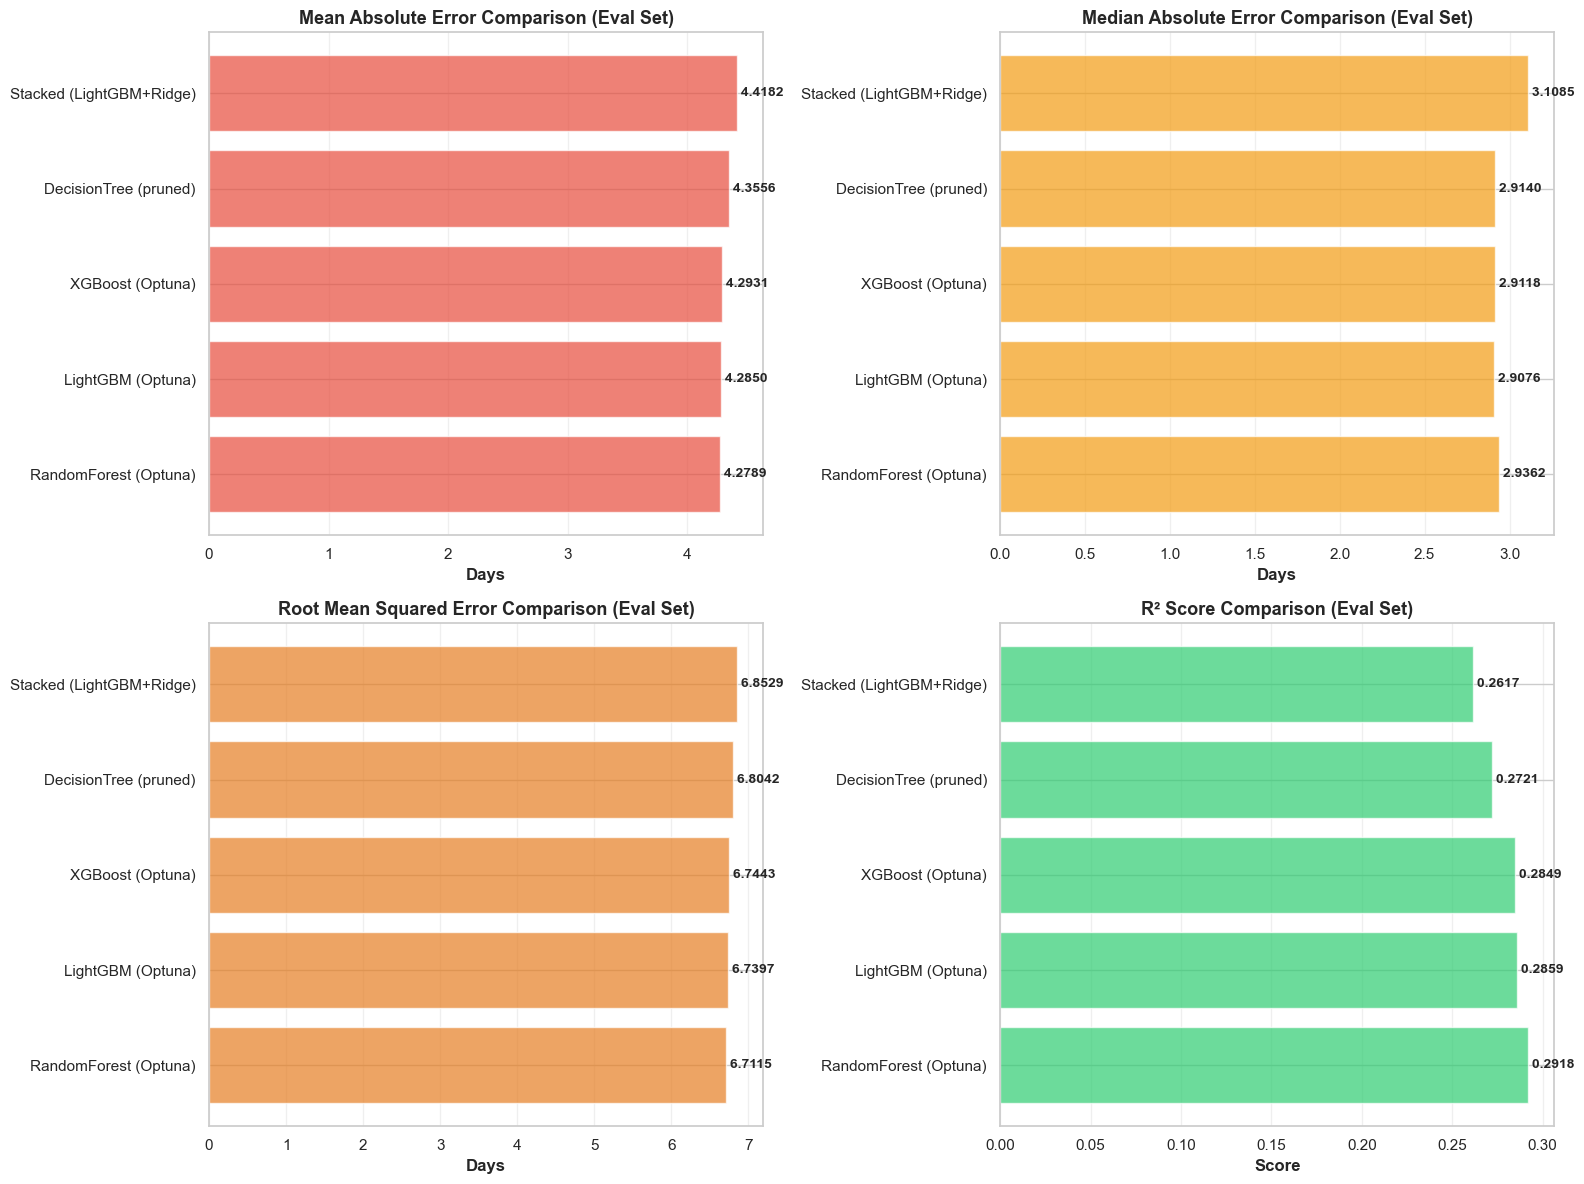

✓ Performance visualization complete


In [ ]:
# Visualize model performance comparison on evaluation set
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics = ['MAE', 'Median_AE', 'RMSE', 'R2']
colors = ['#e74c3c', '#f39c12', '#e67e22', '#2ecc71']
titles = ['Mean Absolute Error', 'Median Absolute Error', 'Root Mean Squared Error', 'R² Score']

for idx, (metric, color, title) in enumerate(zip(metrics, colors, titles)):
    ax = axes[idx // 2, idx % 2]
    values = eval_results_df[metric].values
    models_list = eval_results_df.index.tolist()
    
    bars = ax.barh(models_list, values, color=color, alpha=0.7)
    xlabel = 'Score' if metric == 'R2' else 'Days'
    ax.set_xlabel(xlabel, fontsize=12, fontweight='bold')
    ax.set_title(f'{title} Comparison (Eval Set)', fontsize=13, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    
    # Add value labels
    for i, (bar, value) in enumerate(zip(bars, values)):
        ax.text(value, i, f' {value:.4f}',
                va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("✓ Performance visualization complete")

### 7.4 Feature Importance Analysis

TOP 20 MOST IMPORTANT FEATURES (RandomForest (Optuna))
               Feature  Importance
          distance_log    0.463013
customer_state_encoded    0.293342
           freight_log    0.243646




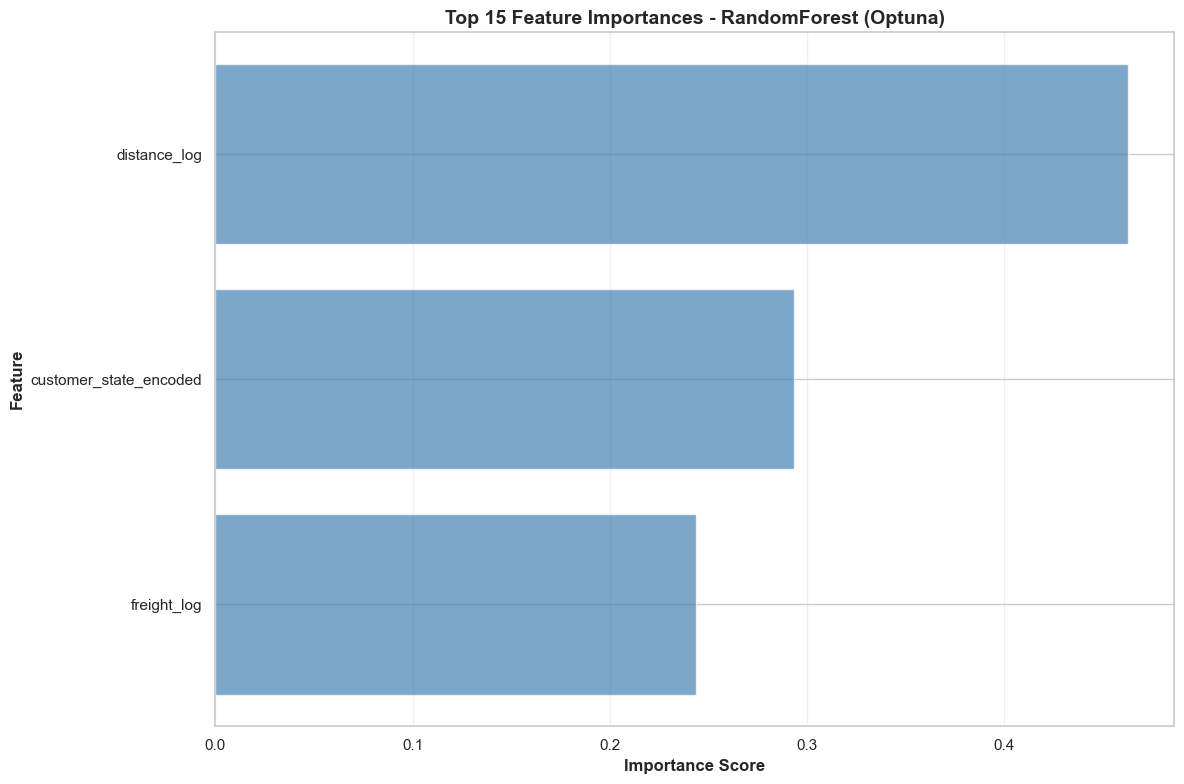

✓ Feature importance analysis complete


In [ ]:
# Get feature importance from best tree-based model
# Try to find a tree-based model
tree_model_names = ['RandomForest (Optuna)', 'LightGBM (Optuna)', 'XGBoost (Optuna)', 'DecisionTree (pruned)']
tree_model = None
tree_model_name = None

for model_name in tree_model_names:
    if model_name in trained_models:
        tree_model = trained_models[model_name]
        tree_model_name = model_name
        break

if tree_model is not None and hasattr(tree_model, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'Feature': final_feature_names,
        'Importance': tree_model.feature_importances_
    }).sort_values('Importance', ascending=False)
    
    # Display top 20 features
    print("=" * 80)
    print(f"TOP 20 MOST IMPORTANT FEATURES ({tree_model_name})")
    print("=" * 80)
    print(feature_importance.head(20).to_string(index=False))
    print("\n")
    
    # Visualize top 15 features
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(top_features['Feature'], top_features['Importance'], color='steelblue', alpha=0.7)
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.ylabel('Feature', fontsize=12, fontweight='bold')
    plt.title(f'Top 15 Feature Importances - {tree_model_name}', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("✓ Feature importance analysis complete")
else:
    print("⚠ No tree-based models available for feature importance analysis")

### 7.5 Prediction vs Actual Visualization

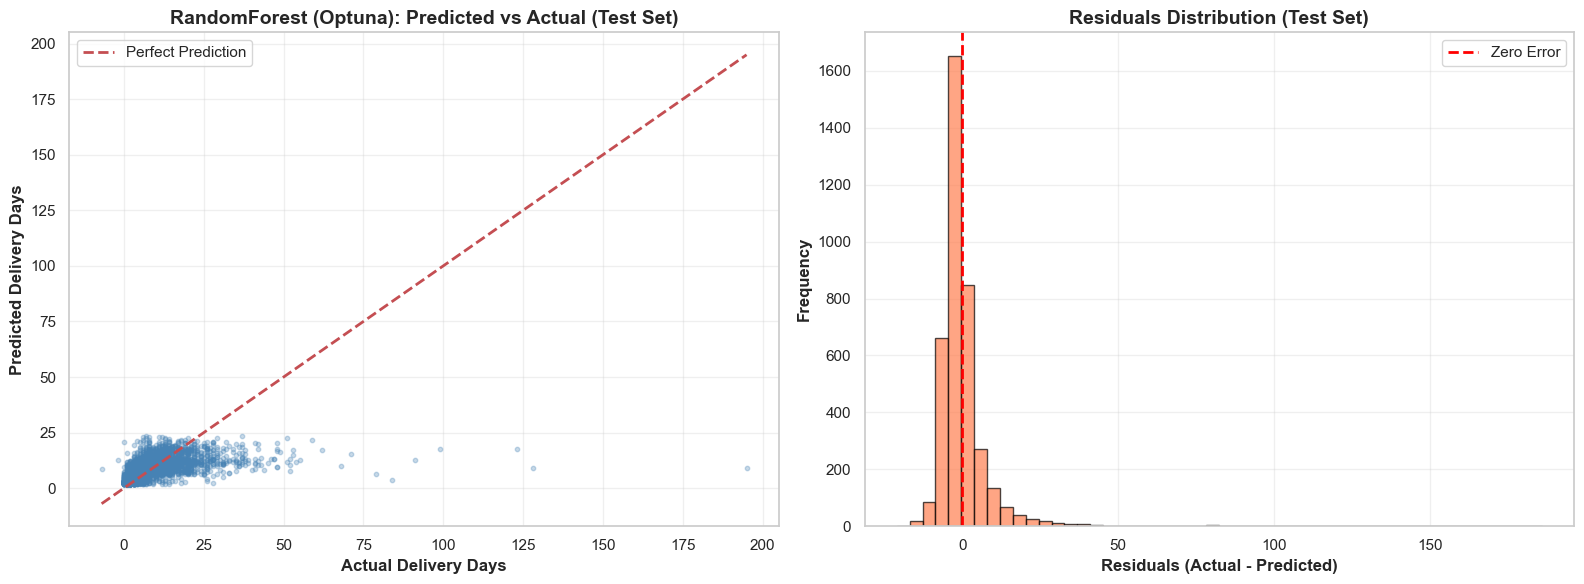

RESIDUAL STATISTICS (TEST SET)
Mean Residual: -0.0229 days
Std Residual: 8.0521 days
Min Residual: -20.9409 days
Max Residual: 185.7164 days

✓ Prediction vs Actual visualization complete


Exception ignored in: <function ResourceTracker.__del__ at 0x1053ba660>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x106fe2660>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x11075e660>
Traceback (most recent call last

In [ ]:
# Get predictions from best model on test set
y_test_pred = best_model.predict(X_test_transformed)

# Create visualizations
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Scatter plot: Predicted vs Actual
ax1 = axes[0]
ax1.scatter(y_test, y_test_pred, alpha=0.3, s=10, color='steelblue')
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Actual Delivery Days', fontsize=12, fontweight='bold')
ax1.set_ylabel('Predicted Delivery Days', fontsize=12, fontweight='bold')
ax1.set_title(f'{best_model_name}: Predicted vs Actual (Test Set)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.3)

# 2. Residuals distribution
ax2 = axes[1]
residuals = y_test - y_test_pred
ax2.hist(residuals, bins=50, color='coral', alpha=0.7, edgecolor='black')
ax2.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Zero Error')
ax2.set_xlabel('Residuals (Actual - Predicted)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Residuals Distribution (Test Set)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print residual statistics
print("=" * 80)
print("RESIDUAL STATISTICS (TEST SET)")
print("=" * 80)
print(f"Mean Residual: {residuals.mean():.4f} days")
print(f"Std Residual: {residuals.std():.4f} days")
print(f"Min Residual: {residuals.min():.4f} days")
print(f"Max Residual: {residuals.max():.4f} days")

print("\n✓ Prediction vs Actual visualization complete")